# Phase 2: segmentation via clustering

This notebook covers Phase 2 of the Home Credit Default Risk project.

This phase segments the combined application table and gives each segment a business interpretation:
1. Reduce dimensions with PCA so distance behaves well, then run K-Means and hierarchical clustering in that space.
2. Compare K from 2 to 10 with several geometric checks, then choose a useful portfolio resolution.
3. Run DBSCAN on a sampled UMAP view to find local density pockets and isolated sampled points.
4. Profile each cluster, give it a business name, and save the naming so later phases can read it.

Input: `datasets/final/features_clustering.csv` (the output of Phase 1).

Outputs land in `results/phase2_clustering/`: the PCA variance table and plot, the K-selection table and elbow plot, cluster labels, the cluster scatter and dendrogram images, the cluster profiles, and `cluster_names.csv`. The written report lives in the project-root `REPORT.md`, not in this notebook.

## 1. Setup and load data

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors
import umap   # readable neighbourhood map for the density view (Section 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
INPUT_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
OUT_DIR = PROJECT_ROOT / 'results/phase2_clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig_atomic(path, **kwargs):
    # Render beside the target, then replace it. On Windows the dashboard,
    # file indexer, or preview pane can briefly hold the previous PNG open.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp{path.suffix}')
    plt.savefig(temp, **kwargs)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

RANDOM_SEED = 42
K_OPTIMAL = 5
N_PCA_CLUSTER = 10   # practical ceiling for a distance-based method

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir  : {OUT_DIR}')

df = pd.read_csv(INPUT_PATH)
print(f'\nLoaded features_clustering: {df.shape[0]:,} rows x {df.shape[1]:,} cols')
df.head()

Project root: C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk
Output dir  : C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering



Loaded features_clustering: 356,255 rows x 42 cols


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TO_ANNUITY,YEARS_EMPLOYED,FLAG_SENTINEL_EMPLOYED,NAME_CONTRACT_TYPE,...,INST_LATE_RATIO,INST_SEVERE_LATE_RATIO,INST_PAYMENT_RATIO_MEAN,POS_SK_DPD_MEAN,POS_MONTHS_COUNT,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_AMT_BALANCE_MEAN,CC_MONTHS_COUNT
0,100002,0.636593,-0.188553,0.067292,-0.719532,-0.644820,-0.583930,-0.579884,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,-0.369704,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
1,100003,1.241984,1.435749,0.746258,0.373208,-0.532854,1.957541,-0.337531,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,0.001164,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
2,100004,-1.675286,-1.736026,-2.324243,-0.722630,-0.885155,-0.129067,-0.761099,0,0,...,-0.641305,-0.200466,0.136549,-0.10476,-0.987817,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
3,100006,-0.216655,-0.557173,0.406269,-0.598481,0.425995,-1.345908,0.476617,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,-0.287289,-0.407481,-0.468926,-0.115527,-0.323456,-0.193504
4,100007,-0.438372,0.137704,-0.157464,0.149965,-0.010731,0.315863,0.476177,0,1,...,1.570353,-0.200466,-0.014824,-0.10476,1.567052,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944


## 2. PCA as a compact clustering space

K-Means and Ward use Euclidean distance, so correlated and noisy axes can
dilute useful structure. PCA rotates the robustly bounded, standardized
feature matrix into orthogonal directions. Ten components are the
compact primary view; they do not satisfy an arbitrary 80%-variance
rule. The notebook reports the actual retained variance and compares the
five-cluster labels against the 80%, 90%, and full-dimensional solutions
using adjusted Rand index, separation, and cluster balance. The profile
section translates the result back to readable business features.


In [2]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score,
)

feature_cols = [c for c in df.columns if c != 'SK_ID_CURR']
X = df[feature_cols].values.astype(np.float32)
print(f'Feature matrix X: {X.shape}')

pca_full = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_SEED)
X_pca50 = pca_full.fit_transform(X)

cumvar = pca_full.explained_variance_ratio_.cumsum()
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
pc11_share = pca_full.explained_variance_ratio_[10] if len(cumvar) > 10 else np.nan
print(f'\nComponents for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'\nPrimary clustering space: PC1-PC{N_PCA_CLUSTER} '
      f'({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance)')
print(f'PC11 itself contributes {pc11_share*100:.2f}% variance. Ten PCs are not an '
      '80%-variance rule; they are the compact primary view, validated below against '
      'the 80%, 90%, and full-dimensional solutions.')

X_cluster = X_pca50[:, :N_PCA_CLUSTER]
X_2d = X_pca50[:, :2]

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumvar,
})
variance_df.to_csv(OUT_DIR / 'pca_variance.csv', index=False)
print(f'\nSaved {OUT_DIR / "pca_variance.csv"}')


Feature matrix X: (356255, 41)



Components for 80% variance: 16
Components for 90% variance: 21

Primary clustering space: PC1-PC10 (64.8% variance)
PC11 itself contributes 3.04% variance. Ten PCs are not an 80%-variance rule; they are the compact primary view, validated below against the 80%, 90%, and full-dimensional solutions.

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\pca_variance.csv


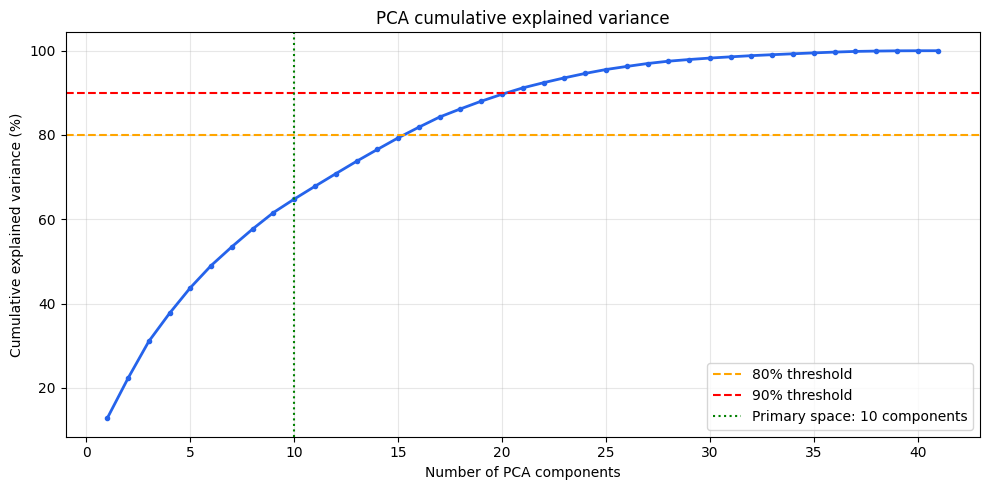

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar*100, marker='o', markersize=3, linewidth=2, color='#2563EB')
ax.axhline(80, color='orange', ls='--', label='80% threshold')
ax.axhline(90, color='red', ls='--', label='90% threshold')
ax.axvline(N_PCA_CLUSTER, color='green', ls=':', label=f'Primary space: {N_PCA_CLUSTER} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA cumulative explained variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'pca_variance_plot.png', dpi=150)
plt.show()

## 3. Choosing the portfolio resolution

K from 2 to 10 is compared on the same reproducible 15,000-application
sample. Every geometric score uses one fixed 5,000-application evaluation
subset, so a change in score reflects K or PCA dimension rather than a
different draw of applications. The normalized elbow, silhouette,
Calinski-Harabasz, Davies-Bouldin, segment balance, and seed stability. The
notebook exports every result. K=5 is compared with K=6 and K=7 because
they are the nearest more-granular alternatives. The operating resolution
must remain stable across seeds, avoid very small groups, and still support
distinct review questions. This notebook does not choose K from one metric.


In [4]:
K_RANGE = range(2, 11)
SAMPLE_SIZE = 15000
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_cluster), size=SAMPLE_SIZE, replace=False)
X_sample = X_cluster[sample_idx]

# Use exactly the same evaluation applications for every K and every PCA
# dimension. Drawing a new subset inside either loop would add sampling
# noise to a comparison that is meant to isolate the modelling choice.
METRIC_SAMPLE_SIZE = min(5000, len(X_sample))
metric_idx = rng.choice(len(X_sample), size=METRIC_SAMPLE_SIZE, replace=False)
pd.DataFrame({
    'SK_ID_CURR': df.iloc[sample_idx[metric_idx]]['SK_ID_CURR'].to_numpy(),
}).to_csv(OUT_DIR / 'metric_evaluation_sample.csv', index=False)

k_results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    metric_x = X_sample[metric_idx]
    metric_labels = labels[metric_idx]
    shares = np.bincount(labels, minlength=k) / len(labels)
    k_results.append({
        'k': k, 'inertia': km.inertia_,
        'silhouette': silhouette_score(metric_x, metric_labels),
        'calinski_harabasz': calinski_harabasz_score(metric_x, metric_labels),
        'davies_bouldin': davies_bouldin_score(metric_x, metric_labels),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
        'time_s': round(time.time()-t0, 2),
    })
    print(f'  K={k:2d} | inertia={km.inertia_:12.1f} | '
          f'sil={k_results[-1]["silhouette"]:.4f} | min share={shares.min():.2%}')

k_df = pd.DataFrame(k_results)
k_df.to_csv(OUT_DIR / 'k_selection.csv', index=False)

# Compare seed stability for the operating resolution and the nearest
# more-granular alternatives.
STABILITY_KS = [5, 6, 7]
STABILITY_SEEDS = [42, 52, 62]
stability_rows = []
for k in STABILITY_KS:
    labels_by_seed = {
        seed: KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=seed).fit_predict(X_sample)
        for seed in STABILITY_SEEDS
    }
    for i, seed_a in enumerate(STABILITY_SEEDS):
        for seed_b in STABILITY_SEEDS[i + 1:]:
            stability_rows.append({
                'k': k, 'seed_a': seed_a, 'seed_b': seed_b,
                'adjusted_rand_index': adjusted_rand_score(
                    labels_by_seed[seed_a], labels_by_seed[seed_b]
                ),
            })
pd.DataFrame(stability_rows).to_csv(OUT_DIR / 'k_stability.csv', index=False)

# Sensitivity to the number of retained principal directions.  This fixes
# the earlier rationale error: PC11 adds its own variance; the decision for
# 10 PCs is accepted only if labels stay close to 80%/90%/full solutions.
dimension_candidates = sorted(set([N_PCA_CLUSTER, n_80, n_90, X.shape[1]]))
dimension_rows = []
dimension_labels = {}
for n_components in dimension_candidates:
    xd = X_pca50[sample_idx, :n_components]
    km_d = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    lbl_d = km_d.fit_predict(xd)
    dimension_labels[n_components] = lbl_d
    shares = np.bincount(lbl_d, minlength=K_OPTIMAL) / len(lbl_d)
    dimension_rows.append({
        'n_components': n_components,
        'retained_variance': cumvar[n_components-1],
        'silhouette': silhouette_score(xd[metric_idx], lbl_d[metric_idx]),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
    })
reference = dimension_labels[N_PCA_CLUSTER]
for row in dimension_rows:
    row['ari_vs_10pc'] = adjusted_rand_score(reference, dimension_labels[row['n_components']])
pd.DataFrame(dimension_rows).to_csv(OUT_DIR / 'pca_cluster_sensitivity.csv', index=False)
k_df


  K= 2 | inertia=    288126.4 | sil=0.2639 | min share=16.64%


  K= 3 | inertia=    254719.4 | sil=0.2681 | min share=2.36%


  K= 4 | inertia=    227064.3 | sil=0.1454 | min share=2.28%


  K= 5 | inertia=    209015.6 | sil=0.1478 | min share=2.26%


  K= 6 | inertia=    196675.8 | sil=0.1523 | min share=1.40%


  K= 7 | inertia=    185244.0 | sil=0.1408 | min share=1.36%


  K= 8 | inertia=    176757.3 | sil=0.1494 | min share=1.34%


  K= 9 | inertia=    169670.9 | sil=0.1418 | min share=1.34%


  K=10 | inertia=    165951.2 | sil=0.1258 | min share=1.33%


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share,max_cluster_share,time_s
0,2,288126.437500,0.263931,826.694754,1.732434,0.166400,0.833600,6.31
1,3,254719.359375,0.268097,790.554258,1.431534,0.023600,0.811933,3.36
2,4,227064.312500,0.145414,780.094081,1.787864,0.022800,0.431200,3.04
3,5,209015.640625,0.147789,746.467491,1.724131,0.022600,0.343533,2.15
4,6,196675.843750,0.152327,690.032896,1.579012,0.014000,0.340600,1.71
5,7,185243.968750,0.140848,659.511367,1.585807,0.013600,0.258867,4.03
6,8,176757.281250,0.149435,631.826325,1.523330,0.013400,0.239200,2.59
7,9,169670.890625,0.141796,602.383348,1.512134,0.013400,0.191933,2.16
8,10,165951.156250,0.125816,555.309923,1.752989,0.013333,0.173000,1.91


Elbow reference          -> K = 5
Highest silhouette score -> K = 3

K=5 evidence: silhouette=0.1478, Davies-Bouldin=1.7241, minimum share=2.26%, mean seed ARI=0.997.
K=6 evidence: silhouette=0.1523, Davies-Bouldin=1.5790, minimum share=1.40%, mean seed ARI=0.743.
K=7 evidence: silhouette=0.1408, Davies-Bouldin=1.5858, minimum share=1.36%, mean seed ARI=0.900.

Selected operating resolution: K = 5
  More-granular alternatives are not retained because seed stability is below 0.90 for K=6, 7.
  Five profiles remain practical to compare and map to five distinct review questions.
  These are portfolio segments for review planning, not applicant risk grades.


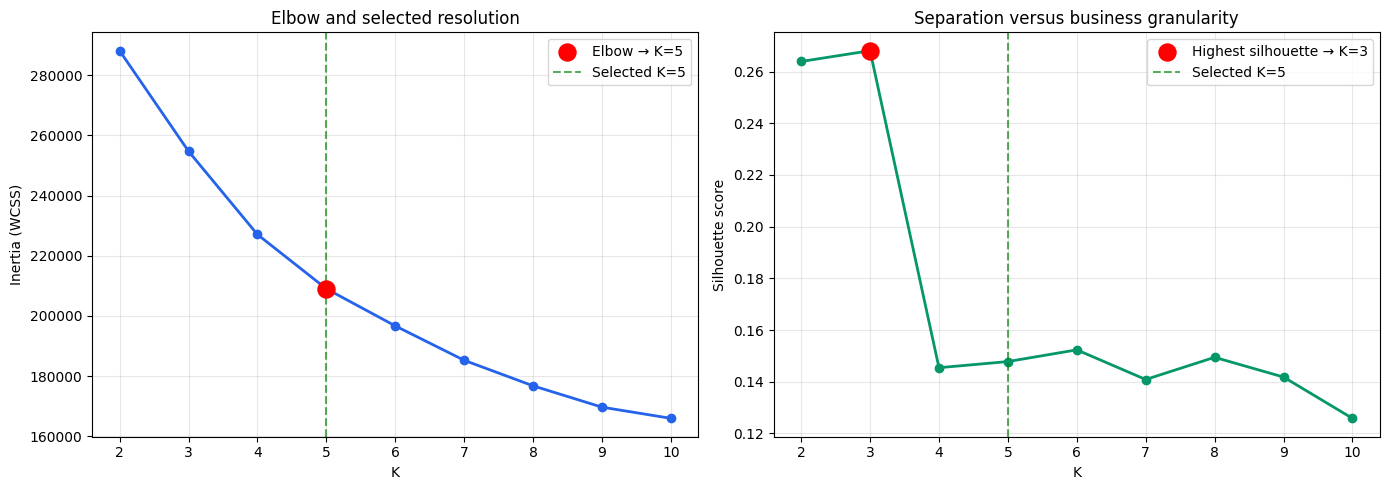

In [5]:
# Normalize both axes before measuring distance to the end-point chord;
# otherwise inertia units dominate K units.  The determinant below is the
# 2-D cross-product magnitude without NumPy's deprecated vector shortcut.
x_norm = (k_df['k'].to_numpy() - k_df['k'].min()) / (k_df['k'].max() - k_df['k'].min())
y_raw = k_df['inertia'].to_numpy()
y_norm = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())
chord = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
points = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
dists = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
elbow_k = int(k_df.iloc[int(np.argmax(dists))]['k'])
best_sil_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
chosen = k_df.loc[k_df['k'].eq(K_OPTIMAL)].iloc[0]
stability_df = pd.read_csv(OUT_DIR / 'k_stability.csv')
stability_mean = stability_df.groupby('k')['adjusted_rand_index'].mean()
alternative = k_df.loc[k_df['k'].eq(6)].iloc[0]
alternative_7 = k_df.loc[k_df['k'].eq(7)].iloc[0]
print(f'Elbow reference          -> K = {elbow_k}')
print(f'Highest silhouette score -> K = {best_sil_k}')
print(f'\nK=5 evidence: silhouette={chosen.silhouette:.4f}, '
      f'Davies-Bouldin={chosen.davies_bouldin:.4f}, '
      f'minimum share={chosen.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[5]:.3f}.')
print(f'K=6 evidence: silhouette={alternative.silhouette:.4f}, '
      f'Davies-Bouldin={alternative.davies_bouldin:.4f}, '
      f'minimum share={alternative.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[6]:.3f}.')
print(f'K=7 evidence: silhouette={alternative_7.silhouette:.4f}, '
      f'Davies-Bouldin={alternative_7.davies_bouldin:.4f}, '
      f'minimum share={alternative_7.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[7]:.3f}.')
print(f'\nSelected operating resolution: K = {K_OPTIMAL}')
unstable_alternatives = [k for k in [6, 7] if stability_mean.loc[k] < 0.90]
if unstable_alternatives:
    print('  More-granular alternatives are not retained because seed stability is below 0.90 for K='
          + ', '.join(map(str, unstable_alternatives)) + '.')
else:
    print('  K=6 and K=7 remain viable sensitivity cases; K=5 is retained for operational comparability.')
print('  Five profiles remain practical to compare and map to five distinct review questions.')
print('  These are portfolio segments for review planning, not applicant risk grades.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_df['k'], k_df['inertia'], 'o-', color='#2563EB', linewidth=2)
axes[0].scatter([elbow_k], [k_df.loc[k_df['k']==elbow_k, 'inertia'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Elbow → K={elbow_k}')
axes[0].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow and selected resolution'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(k_df['k'], k_df['silhouette'], 'o-', color='#059669', linewidth=2)
axes[1].scatter([best_sil_k], [k_df.loc[k_df['k']==best_sil_k, 'silhouette'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Highest silhouette → K={best_sil_k}')
axes[1].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Separation versus business granularity'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); savefig_atomic(OUT_DIR / 'elbow_plot.png', dpi=160, bbox_inches='tight'); plt.show()


### Is a silhouette of 0.15 a weak result or a wrong one?

A silhouette this low invites an obvious conclusion: the clustering failed. That conclusion needs testing rather than accepting, because three quite different situations produce the same number, and they call for opposite responses.

1. **The data has no cluster structure.** Then any partition is arbitrary and nothing downstream should lean on it.
2. **The structure exists but the method is losing it**, through preprocessing, dimension reduction, or a wrong K.
3. **The structure exists and there is more than one of it.** Several strong but mutually incompatible groupings, forced into a single Euclidean partition, produce a compromise that separates none of them well.

The three diagnostics below distinguish these. Reporting a low silhouette without them would leave the reader unable to tell an empty result from an informative one.

**Hopkins statistic** asks whether the data clusters at all. It compares how far real points sit from their nearest real neighbour against how far uniformly random points sit from the nearest real point. Near 0.5 means the data is spread like a uniform cloud; near 1.0 means it concentrates. A uniform reference is scored alongside as a control on the implementation.

**Null-model silhouette** asks whether the observed value beats chance. Two nulls are used: a column-wise shuffle, which preserves every marginal distribution and destroys only the joint structure, and a uniform draw over the same bounding box. Silhouette on the real data has to beat both before it can be called structure.

That second null carries a trap worth watching for. Silhouette rewards a split that isolates a tiny distant group, so a heavily skewed feature can score very well while telling nobody anything. The cell prints group sizes next to each score precisely so that a high number produced by a 1-percent-against-99-percent split is visible as the degenerate result it is.

**Silhouette by feature family** asks where the separation lives. Each family is clustered on its own and scored. If families score well alone but poorly together, the portfolio has several overlapping segmentations rather than one.


In [6]:
# --------------------------- does this portfolio cluster at all, and how?
from sklearn.metrics import silhouette_score as _sil

TENDENCY_SAMPLE = 20000
rng_t = np.random.default_rng(RANDOM_SEED)
t_idx = rng_t.choice(len(X), size=TENDENCY_SAMPLE, replace=False)
X_t = X[t_idx]
Xp_t = PCA(n_components=N_PCA_CLUSTER, random_state=RANDOM_SEED).fit_transform(X_t).astype(np.float32)

def hopkins(data, frac=0.05, seed=RANDOM_SEED):
    """Near 0.5 means no cluster tendency; near 1.0 means the data concentrates."""
    r = np.random.default_rng(seed)
    rows, dims = data.shape
    m = max(int(frac * rows), 50)
    index = NearestNeighbors(n_neighbors=2).fit(data)
    synthetic = r.uniform(data.min(axis=0), data.max(axis=0), size=(m, dims)).astype(np.float32)
    u = index.kneighbors(synthetic, n_neighbors=1)[0].ravel()
    w = index.kneighbors(data[r.choice(rows, size=m, replace=False)], n_neighbors=2)[0][:, 1]
    return float(u.sum() / (u.sum() + w.sum()))

uniform_ref = rng_t.uniform(Xp_t.min(axis=0), Xp_t.max(axis=0), size=Xp_t.shape).astype(np.float32)
hop_rows = [
    {'space': f'Portfolio sample, {N_PCA_CLUSTER}-component space',
     'hopkins': float(np.mean([hopkins(Xp_t, seed=RANDOM_SEED + i) for i in range(3)]))},
    {'space': f'Portfolio sample, all {X.shape[1]} dimensions',
     'hopkins': float(np.mean([hopkins(X_t, seed=RANDOM_SEED + i) for i in range(3)]))},
    {'space': 'Uniform reference (implementation control)', 'hopkins': hopkins(uniform_ref)},
]
hopkins_frame = pd.DataFrame(hop_rows)
print('Cluster tendency (0.5 = spread like a uniform cloud, 1.0 = strongly concentrated):')
print(hopkins_frame.round(4).to_string(index=False))

# --------------------------------------------------- null-model comparison
X_shuffled = X_t.copy()
for column in range(X_shuffled.shape[1]):
    X_shuffled[:, column] = X_shuffled[rng_t.permutation(len(X_shuffled)), column]
Xp_shuffled = PCA(n_components=N_PCA_CLUSTER, random_state=RANDOM_SEED).fit_transform(X_shuffled).astype(np.float32)
Xp_uniform = PCA(n_components=N_PCA_CLUSTER, random_state=RANDOM_SEED).fit_transform(uniform_ref).astype(np.float32)

sil_idx = rng_t.choice(TENDENCY_SAMPLE, size=5000, replace=False)
null_rows = []
for k in (2, 3, K_OPTIMAL, 6, 7):
    entry = {'k': k}
    for label, data in (('real', Xp_t), ('shuffled', Xp_shuffled), ('uniform', Xp_uniform)):
        assignment = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit_predict(data)
        shares = np.bincount(assignment, minlength=k) / len(assignment)
        entry[f'{label}_silhouette'] = float(_sil(data[sil_idx], assignment[sil_idx]))
        entry[f'{label}_smallest_group'] = float(shares.min())
    entry['gap_vs_shuffled'] = entry['real_silhouette'] - entry['shuffled_silhouette']
    null_rows.append(entry)
null_frame = pd.DataFrame(null_rows)
null_frame['degenerate_null'] = null_frame['shuffled_smallest_group'] < 0.02
null_frame.to_csv(OUT_DIR / 'cluster_tendency.csv', index=False)

print()
print('Silhouette against two null models, with the smallest group share beside each:')
print(null_frame[['k', 'real_silhouette', 'real_smallest_group', 'shuffled_silhouette',
                  'shuffled_smallest_group', 'uniform_silhouette', 'gap_vs_shuffled',
                  'degenerate_null']].round(4).to_string(index=False))

chosen_row = null_frame.loc[null_frame['k'].eq(K_OPTIMAL)].iloc[0]
print()
print(f"At the operating resolution K={K_OPTIMAL}, the real silhouette of "
      f"{chosen_row['real_silhouette']:.4f} exceeds both nulls "
      f"({chosen_row['shuffled_silhouette']:.4f} shuffled, {chosen_row['uniform_silhouette']:.4f} uniform).")
degenerate = null_frame[null_frame['degenerate_null']]
if len(degenerate):
    worst = degenerate.loc[degenerate['shuffled_silhouette'].idxmax()]
    print(f"Watch the low-K rows. At K={int(worst['k'])} the shuffled null scores "
          f"{worst['shuffled_silhouette']:.4f}, higher than the real data, by isolating a group of "
          f"{worst['shuffled_smallest_group']:.2%}. That is silhouette rewarding a degenerate split on a")
    print("skewed axis, not evidence of structure, which is why group sizes are printed here and why")
    print("a silhouette on this portfolio must not be read against a textbook threshold.")

# ------------------------------------------- where does the separation live?
FAMILIES = {
    'Affordability (amounts and ratios)': ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
        'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_ANNUITY', 'GOODS_TO_CREDIT'],
    'Instalment delinquency': ['INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO',
        'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'],
    'Card history': ['CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN', 'CC_MONTHS_COUNT'],
    'Relationship depth (counts)': ['PREV_COUNT', 'BUREAU_COUNT', 'INST_COUNT', 'POS_MONTHS_COUNT'],
}
family_rows = []
for name, wanted in FAMILIES.items():
    use = [c for c in wanted if c in feature_cols]
    if len(use) < 2:
        continue
    block = X_t[:, [feature_cols.index(c) for c in use]]
    assignment = KMeans(n_clusters=K_OPTIMAL, n_init=10, random_state=RANDOM_SEED).fit_predict(block)
    family_rows.append({
        'feature_family': name, 'features': len(use),
        'silhouette_alone': float(_sil(block[sil_idx], assignment[sil_idx])),
    })
family_rows.append({
    'feature_family': f'All {X.shape[1]} governed features together',
    'features': X.shape[1],
    'silhouette_alone': float(chosen_row['real_silhouette']),
})
family_frame = pd.DataFrame(family_rows).sort_values('silhouette_alone', ascending=False)
family_frame.to_csv(OUT_DIR / 'silhouette_by_feature_family.csv', index=False)

print()
print(f'Silhouette when each feature family is clustered on its own, K={K_OPTIMAL}:')
print(family_frame.round(4).to_string(index=False))
best_family = family_frame.iloc[0]
print()
print(f"{best_family['feature_family']} separates at {best_family['silhouette_alone']:.3f} on its own, "
      f"against {chosen_row['real_silhouette']:.3f} for the combined matrix.")
print('Families that separate well alone but poorly together is the signature of a portfolio')
print('carrying several overlapping segmentations. Card history splits it into applicants with')
print('and without a card record, delinquency into applicants with and without recorded lateness,')
print('and affordability varies continuously with no gap at all. One Euclidean partition cannot')
print('serve three incompatible groupings, and the compromise is what the combined silhouette')
print('measures. The low value is therefore a finding about the portfolio, not a failed run.')
del X_t, Xp_t, X_shuffled, Xp_shuffled, Xp_uniform, uniform_ref


Cluster tendency (0.5 = spread like a uniform cloud, 1.0 = strongly concentrated):
                                     space  hopkins
      Portfolio sample, 10-component space   0.8814
       Portfolio sample, all 41 dimensions   0.8338
Uniform reference (implementation control)   0.4982



Silhouette against two null models, with the smallest group share beside each:
 k  real_silhouette  real_smallest_group  shuffled_silhouette  shuffled_smallest_group  uniform_silhouette  gap_vs_shuffled  degenerate_null
 2           0.2586               0.1693               0.6740                   0.0091              0.1605          -0.4154             True
 3           0.1400               0.1592               0.5057                   0.0091              0.1216          -0.3657             True
 5           0.1542               0.0222               0.1103                   0.0091              0.1029           0.0438             True
 6           0.1432               0.0217               0.1129                   0.0091              0.1017           0.0303             True
 7           0.1467               0.0146               0.1125                   0.0090              0.0922           0.0343             True

At the operating resolution K=5, the real silhouette of 0.1542 exceeds bo


Silhouette when each feature family is clustered on its own, K=5:
                    feature_family  features  silhouette_alone
                      Card history         4            0.8452
            Instalment delinquency         6            0.6849
       Relationship depth (counts)         4            0.3469
Affordability (amounts and ratios)         6            0.2643
 All 41 governed features together        41            0.1542

Card history separates at 0.845 on its own, against 0.154 for the combined matrix.
Families that separate well alone but poorly together is the signature of a portfolio
carrying several overlapping segmentations. Card history splits it into applicants with
and without a card record, delinquency into applicants with and without recorded lateness,
and affordability varies continuously with no gap at all. One Euclidean partition cannot
serve three incompatible groupings, and the compromise is what the combined silhouette
measures. The low value is the

### Seed stability is not sample stability

The Adjusted Rand Index reported above compares runs that differ only in the random seed, on one fixed sample. That answers a narrow question: does the optimiser land in the same place twice? It cannot answer the question a reviewer actually cares about, which is whether the five segments are a property of the portfolio or of the particular applications that happened to be drawn.

Those two things come apart in practice. A partition can be perfectly seed-stable and still dissolve when a different half of the data is used, because K-Means will always converge reliably onto a boundary it has cut through a continuum. Reporting only seed stability would therefore overstate how solid the segments are, and the low silhouette already warns that some of these boundaries pass through continuous regions.

The split-half test below is the honest version. Two disjoint halves of the portfolio are drawn, K-Means is fitted independently on each, and both fitted models then label the same third, previously unseen set of applications. The Adjusted Rand Index between those two labellings measures agreement between two models that never saw the same data. Five independent splits are run per K so the result is not one lucky draw, and K equal to 6 and 7 are included so the operating choice is defended on sample stability as well as on seed stability.


In [7]:
# ------------------------------------- split-half (sample) stability
# Two disjoint halves, two independent fits, one common unseen evaluation set.
SPLIT_TRIALS = 5
SPLIT_FIT_ROWS = 20000
SPLIT_EVAL_ROWS = 10000

split_rows = []
for k in STABILITY_KS:
    for trial in range(SPLIT_TRIALS):
        rng_s = np.random.default_rng(RANDOM_SEED + 1000 * trial + k)
        draw = rng_s.choice(
            len(X_cluster), size=2 * SPLIT_FIT_ROWS + SPLIT_EVAL_ROWS, replace=False)
        fit_a = draw[:SPLIT_FIT_ROWS]
        fit_b = draw[SPLIT_FIT_ROWS:2 * SPLIT_FIT_ROWS]
        evaluate = draw[2 * SPLIT_FIT_ROWS:]
        model_a = KMeans(n_clusters=k, n_init=10, max_iter=300,
                         random_state=RANDOM_SEED).fit(X_cluster[fit_a])
        model_b = KMeans(n_clusters=k, n_init=10, max_iter=300,
                         random_state=RANDOM_SEED).fit(X_cluster[fit_b])
        split_rows.append({
            'k': k, 'trial': trial,
            'adjusted_rand_index': adjusted_rand_score(
                model_a.predict(X_cluster[evaluate]),
                model_b.predict(X_cluster[evaluate])),
        })
split_stability = pd.DataFrame(split_rows)
split_summary = split_stability.groupby('k')['adjusted_rand_index'].agg(
    ['mean', 'min', 'max']).reset_index()
split_summary.columns = ['k', 'split_half_ari_mean', 'split_half_ari_min', 'split_half_ari_max']
split_summary['seed_ari_mean'] = split_summary['k'].map(stability_mean)
split_summary['stability_gap'] = (
    split_summary['seed_ari_mean'] - split_summary['split_half_ari_mean'])
split_summary.to_csv(OUT_DIR / 'k_split_half_stability.csv', index=False)

print(f'Split-half stability: {SPLIT_TRIALS} independent splits per K, '
      f'{SPLIT_FIT_ROWS:,} rows per fit, {SPLIT_EVAL_ROWS:,} unseen rows scored by both models.')
print(split_summary.round(4).to_string(index=False))

chosen_split = split_summary.loc[split_summary['k'].eq(K_OPTIMAL)].iloc[0]
print(f"\nK={K_OPTIMAL}: seed ARI {chosen_split['seed_ari_mean']:.3f}, "
      f"split-half ARI {chosen_split['split_half_ari_mean']:.3f} "
      f"(range {chosen_split['split_half_ari_min']:.3f} to {chosen_split['split_half_ari_max']:.3f}).")
for _, row in split_summary.iterrows():
    if int(row['k']) == K_OPTIMAL:
        continue
    print(f"K={int(row['k'])}: seed ARI {row['seed_ari_mean']:.3f}, "
          f"split-half ARI {row['split_half_ari_mean']:.3f}.")
print()
print('The gap between the two columns is the part of apparent stability that comes from')
print('reusing one sample. A partition that holds across disjoint halves is describing the')
print('portfolio; one that only holds across seeds is describing the optimiser.')


Split-half stability: 5 independent splits per K, 20,000 rows per fit, 10,000 unseen rows scored by both models.
 k  split_half_ari_mean  split_half_ari_min  split_half_ari_max  seed_ari_mean  stability_gap
 5               0.9550              0.9369              0.9734         0.9967         0.0417
 6               0.6702              0.5885              0.9432         0.7427         0.0725
 7               0.8149              0.6013              0.9509         0.9000         0.0851

K=5: seed ARI 0.997, split-half ARI 0.955 (range 0.937 to 0.973).
K=6: seed ARI 0.743, split-half ARI 0.670.
K=7: seed ARI 0.900, split-half ARI 0.815.

The gap between the two columns is the part of apparent stability that comes from
reusing one sample. A partition that holds across disjoint halves is describing the
portfolio; one that only holds across seeds is describing the optimiser.


## 4. K-Means on all 356,255 combined applications

In [8]:
print('Running K-Means (K=5) on full data ...')
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s | Inertia = {kmeans.inertia_:.1f}')

rng2 = np.random.default_rng(RANDOM_SEED)
sil_idx = rng2.choice(len(X_cluster), size=10000, replace=False)
sil_kmeans = silhouette_score(X_cluster[sil_idx], kmeans_labels[sil_idx])
print(f'  Silhouette Score (sample 10K): {sil_kmeans:.4f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f'\nK-Means segment distribution:')
for cid, cnt in zip(unique, counts):
    pct = cnt/len(kmeans_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} applications ({pct:5.1f}%) {"█"*int(pct/2)}')

Running K-Means (K=5) on full data ...


  Done in 5.3s | Inertia = 4950973.5


  Silhouette Score (sample 10K): 0.1516

K-Means segment distribution:
  Cluster 0:  51,614 applications ( 14.5%) ███████
  Cluster 1: 123,344 applications ( 34.6%) █████████████████
  Cluster 2: 119,127 applications ( 33.4%) ████████████████
  Cluster 3:   7,626 applications (  2.1%) █
  Cluster 4:  54,544 applications ( 15.3%) ███████


In [9]:
# ---------------------------------------------- per-segment silhouette
# A single portfolio silhouette hides which segments are genuinely separated
# and which are a cut through a continuum. Reporting the value per segment is
# the honest version of the same statistic and it drives the interpretation in
# Section 10: a segment with a near-zero score must not be described as a
# naturally occurring group.
from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(X_cluster[sil_idx], kmeans_labels[sil_idx])
per_cluster_sil = pd.DataFrame({
    'cluster_id': kmeans_labels[sil_idx],
    'silhouette': sil_values,
}).groupby('cluster_id')['silhouette'].agg(['mean', 'median', 'size']).reset_index()
per_cluster_sil['share_negative'] = pd.DataFrame({
    'cluster_id': kmeans_labels[sil_idx], 's': sil_values
}).groupby('cluster_id')['s'].apply(lambda s: (s < 0).mean()).values
per_cluster_sil.to_csv(OUT_DIR / 'cluster_silhouette_detail.csv', index=False)

print('Per-segment silhouette (10,000-application sample):')
print(per_cluster_sil.round(4).to_string(index=False))
print('\nA share_negative above ~0.25 means many members sit closer to another segment\'s')
print('centre than to their own, so that segment is a boundary in a continuum rather')
print('than an isolated group. Section 10 names those segments accordingly.')


Per-segment silhouette (10,000-application sample):
 cluster_id   mean  median  size  share_negative
          0 0.0841  0.0643  1463          0.2556
          1 0.1336  0.1290  3529          0.0774
          2 0.1828  0.1840  3299          0.0000
          3 0.2215  0.2449   238          0.1765
          4 0.1803  0.1912  1471          0.0673

A share_negative above ~0.25 means many members sit closer to another segment's
centre than to their own, so that segment is a boundary in a continuum rather
than an isolated group. Section 10 names those segments accordingly.


## 5. DBSCAN over the whole portfolio

DBSCAN asks a different question from K-Means: which applications lack a sufficiently dense local neighbourhood? An earlier version of this notebook answered that on a 30,000-application UMAP sample and justified it as the full run being intractable. That justification was wrong and the correction is worth stating plainly, because it changes what the result can be used for.

Two different costs were being conflated. **UMAP** is genuinely expensive: 103 seconds for 30,000 rows, scaling superlinearly, so embedding the full portfolio is impractical here. **DBSCAN itself** is not: in the 10-component space a spatial index keeps it close to O(n log n), and the run below finishes on all 356,255 applications. Describing the whole thing as intractable presented an operating-convenience choice as an algorithmic limit.

The density view is therefore split along the line that actually exists:

* **DBSCAN runs on every application** in the 10-component PCA space, which preserves linear distance. Nothing is sampled and no projection is involved, so its noise flag is a portfolio fact rather than an estimate from 8.4 percent of the data. This is what Phase 4 reads.
* **UMAP stays as a picture** in Section 5b, and as one half of the two-space agreement check. It no longer decides anything.

One economy remains and is named rather than hidden. The `eps` knee is estimated from a 30,000-row query subsample against an index fitted on **all** rows, instead of querying every row. The knee is a property of the distance distribution, which 30,000 draws estimate precisely, and querying all 356,255 rows costs roughly ten times as long for the same answer. The clustering that follows uses every row.

In [10]:
# ------------------------- DBSCAN over the full portfolio (10-component space)
MIN_SAMPLES = 15
KNEE_QUERY_SAMPLE = 30000

print(f'Step 1 - k-distance knee from {KNEE_QUERY_SAMPLE:,} query rows against an index '
      f'fitted on all {len(X_cluster):,} applications ...')
t0 = time.time()
rng_knee = np.random.default_rng(RANDOM_SEED)
knee_query = rng_knee.choice(len(X_cluster), size=KNEE_QUERY_SAMPLE, replace=False)
nn_full = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1).fit(X_cluster)
kdist_full = np.sort(nn_full.kneighbors(X_cluster[knee_query])[0][:, -1])
xx = np.linspace(0, 1, len(kdist_full))
yy = (kdist_full - kdist_full.min()) / max(kdist_full.max() - kdist_full.min(), 1e-12)
chord = np.array([1.0, yy[-1] - yy[0]])
points = np.column_stack([xx, yy - yy[0]])
dline = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
EPS_FULL = float(round(kdist_full[int(np.argmax(dline))], 3))
print(f'  Done in {time.time()-t0:.1f}s | eps = {EPS_FULL}')

print(f'\nStep 2 - DBSCAN on all {len(X_cluster):,} applications '
      f'(eps={EPS_FULL}, min_samples={MIN_SAMPLES}). This takes roughly 25 minutes ...')
t0 = time.time()
dbscan_full_labels = DBSCAN(eps=EPS_FULL, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s')

noise_mask_full = dbscan_full_labels == -1
n_noise_full = int(noise_mask_full.sum())
n_pockets_full = len(set(dbscan_full_labels)) - (1 if -1 in dbscan_full_labels else 0)
print(f'  Density pockets: {n_pockets_full}')
print(f'  Noise points: {n_noise_full:,} ({n_noise_full / len(X_cluster):.2%} of the portfolio)')
print('  Every application received a density label, so nothing downstream needs a')
print('  sampled denominator or an unassessed state.')

# Profile the noise, so the count means something to a reviewer.
profile_cols = [c for c in ['AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME', 'ANNUITY_TO_INCOME',
                            'PREV_COUNT', 'PREV_REFUSED_COUNT', 'INST_COUNT', 'INST_LATE_RATIO',
                            'CC_UTILIZATION_MEAN', 'BUREAU_COUNT'] if c in feature_cols]
col_pos = [feature_cols.index(c) for c in profile_cols]
noise_profile = pd.DataFrame({
    'feature': profile_cols,
    'noise_mean_sd': X[np.ix_(noise_mask_full, col_pos)].mean(axis=0),
    'dense_mean_sd': X[np.ix_(~noise_mask_full, col_pos)].mean(axis=0),
})
noise_profile['gap_sd'] = noise_profile['noise_mean_sd'] - noise_profile['dense_mean_sd']
noise_profile = noise_profile.reindex(
    noise_profile['gap_sd'].abs().sort_values(ascending=False).index)
noise_profile.to_csv(OUT_DIR / 'dbscan_noise_profile.csv', index=False)
print('\nWhat the isolated applications look like (portfolio standard deviations):')
print(noise_profile.round(3).to_string(index=False))

pocket_sizes = pd.Series(dbscan_full_labels[~noise_mask_full]).value_counts()
print(f'\nLargest density pocket holds {pocket_sizes.iloc[0]:,} applications '
      f'({pocket_sizes.iloc[0] / len(X_cluster):.1%}); pockets under 100 applications: '
      f'{int((pocket_sizes < 100).sum())}.')
print('DBSCAN describes local density here; it does not propose a competing segmentation.')


Step 1 - k-distance knee from 30,000 query rows against an index fitted on all 356,255 applications ...


  Done in 23.1s | eps = 2.075

Step 2 - DBSCAN on all 356,255 applications (eps=2.075, min_samples=15). This takes roughly 25 minutes ...


  Done in 1997.6s
  Density pockets: 9
  Noise points: 12,402 (3.48% of the portfolio)
  Every application received a density label, so nothing downstream needs a
  sampled denominator or an unassessed state.



What the isolated applications look like (portfolio standard deviations):
            feature  noise_mean_sd  dense_mean_sd  gap_sd
    INST_LATE_RATIO          0.941         -0.034   0.974
         INST_COUNT          0.840         -0.030   0.871
 PREV_REFUSED_COUNT          0.797         -0.029   0.825
CC_UTILIZATION_MEAN          0.700         -0.025   0.725
         PREV_COUNT          0.691         -0.025   0.716
       BUREAU_COUNT          0.202         -0.007   0.209
  ANNUITY_TO_INCOME          0.182         -0.007   0.189
   CREDIT_TO_INCOME          0.149         -0.005   0.155
        AMT_ANNUITY          0.077         -0.003   0.080
         AMT_CREDIT          0.025         -0.001   0.026

Largest density pocket holds 343,050 applications (96.3%); pockets under 100 applications: 6.
DBSCAN describes local density here; it does not propose a competing segmentation.


### 5b. The UMAP view, kept as a picture and as a cross-check

A two-dimensional embedding is the only way to actually *look* at neighbourhood structure, so the UMAP view stays. What changes is its status: it is a visualisation and a robustness check, not the source of any flag.

The check is worth running because a projection can invent structure. DBSCAN is applied to the same 30,000 applications in the UMAP embedding, and its noise set is compared with the full-portfolio result restricted to those same rows. Agreement would mean the embedding preserved what matters; disagreement means the picture is a picture, and the numbers must come from the distance-preserving space.


In [11]:
# UMAP embedding of a reproducible sample, for the picture and the cross-check.
DBSCAN_SAMPLE = 30000
rng3 = np.random.default_rng(RANDOM_SEED)
dbscan_idx = rng3.choice(len(X), size=DBSCAN_SAMPLE, replace=False)
X_db_raw = X[dbscan_idx]

representativeness = pd.DataFrame({
    'feature': feature_cols,
    'portfolio_mean': X.mean(axis=0),
    'sample_mean': X_db_raw.mean(axis=0),
})
representativeness['abs_mean_gap'] = (
    representativeness['sample_mean'] - representativeness['portfolio_mean']).abs()
representativeness.to_csv(OUT_DIR / 'dbscan_sample_validation.csv', index=False)

print(f'UMAP embedding {DBSCAN_SAMPLE:,} x {X_db_raw.shape[1]} features -> 2D ...')
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0,
                    metric='euclidean', random_state=RANDOM_SEED)
X_umap = reducer.fit_transform(X_db_raw)
print(f'  Done in {time.time()-t0:.1f}s')

nn_u = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_umap)
kd_u = np.sort(nn_u.kneighbors(X_umap)[0][:, -1])
xx = np.linspace(0, 1, len(kd_u))
yy = (kd_u - kd_u.min()) / max(kd_u.max() - kd_u.min(), 1e-12)
chord_u = np.array([1.0, yy[-1] - yy[0]])
pts_u = np.column_stack([xx, yy - yy[0]])
d_u = np.abs(chord_u[0] * pts_u[:, 1] - chord_u[1] * pts_u[:, 0]) / np.linalg.norm(chord_u)
EPS = float(round(kd_u[int(np.argmax(d_u))], 3))
dbscan_labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_umap)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
pct_noise = n_noise / len(dbscan_labels) * 100
print(f'  UMAP-space DBSCAN: eps={EPS}, {n_clusters_db} pockets, {n_noise:,} noise ({pct_noise:.1f}%)')

# Cross-check: the same rows, judged in two spaces.
noise_umap = dbscan_labels == -1
noise_pca_same_rows = dbscan_full_labels[dbscan_idx] == -1
intersection = int((noise_umap & noise_pca_same_rows).sum())
union = int((noise_umap | noise_pca_same_rows).sum())
jaccard_space = intersection / union if union else 0.0

space_check = pd.DataFrame([{
    'space': 'UMAP 2D (visualisation only)', 'rows_assessed': DBSCAN_SAMPLE, 'eps': EPS,
    'noise_points': int(noise_umap.sum()), 'noise_share': float(noise_umap.mean()),
    'density_pockets': n_clusters_db, 'decides_downstream_flags': False,
}, {
    'space': '10-component PCA (operating view)', 'rows_assessed': len(X_cluster), 'eps': EPS_FULL,
    'noise_points': n_noise_full, 'noise_share': float(noise_mask_full.mean()),
    'density_pockets': n_pockets_full, 'decides_downstream_flags': True,
}])
space_check['agreement_jaccard_on_shared_rows'] = jaccard_space
space_check.to_csv(OUT_DIR / 'dbscan_space_comparison.csv', index=False)
print()
print(space_check.to_string(index=False))
print(f'\nOn the {DBSCAN_SAMPLE:,} applications both spaces judged, noise agreement is '
      f'Jaccard {jaccard_space:.3f} ({intersection:,} shared of {union:,} flagged in either).')
print('Low agreement is why the UMAP result is a picture and the PCA result is the flag.')


UMAP embedding 30,000 x 41 features -> 2D ...


C:\Users\mario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 188.1s


  UMAP-space DBSCAN: eps=0.102, 29 pockets, 519 noise (1.7%)

                            space  rows_assessed   eps  noise_points  noise_share  density_pockets  decides_downstream_flags  agreement_jaccard_on_shared_rows
     UMAP 2D (visualisation only)          30000 0.102           519     0.017300               29                     False                           0.04331
10-component PCA (operating view)         356255 2.075         12402     0.034812                9                      True                           0.04331

On the 30,000 applications both spaces judged, noise agreement is Jaccard 0.043 (67 shared of 1,547 flagged in either).
Low agreement is why the UMAP result is a picture and the PCA result is the flag.


## 6. Hierarchical clustering: what scale is actually possible

Exact agglomerative clustering on 356,255 applications needs the full pairwise distance matrix: 63.46 billion distances, which is 236 GB as float32 before SciPy's working copy. That is an algorithmic wall, not a resource preference, and an attempt to run it fails with an allocation error for 242 GiB. So the question is not whether to approximate, but which approximation to trust.

Two are run here and they are not equivalent.

**BIRCH over every application** is the primary hierarchical validation. It summarises the portfolio into a CF-tree, then applies agglomerative clustering to those summaries, so every one of the 356,255 applications participates in the tree. Its threshold is the parameter that matters and it is not free: at 0.5 the tree barely compresses (about 254,000 subclusters) and the final agglomeration hits the same 242 GiB wall, while a threshold of 2.0 compresses to roughly 9,000 subclusters and completes in seconds. That sensitivity is a real property of the method and is printed below rather than hidden behind a default.

**Sampled Ward with nearest-centroid assignment** is retained only as a contrast, because it is the approximation the earlier version of this report relied on and its bias is worth showing. Ward is fitted on 5,000 rows, five centroids are formed, and the whole portfolio is assigned to the nearest one. That final step produces a convex Voronoi partition, which is exactly the shape K-Means produces, so comparing the two measures how close two sets of five centroids are rather than whether hierarchical structure resembles K-Means structure. The comparison is biased toward agreement, and the two Adjusted Rand Index values below quantify by how much.

A dendrogram and the cophenetic correlation stay on samples for reasons that are intrinsic rather than practical. A dendrogram with 356,255 leaves is unreadable at any resolution, so sampling there is a visualisation decision. Cophenetic correlation is *defined* as the correlation between the condensed pairwise distance vector and the cophenetic distance vector, so it needs the same matrix that is impossible to hold.

In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

# ---------------------------- 1. BIRCH over every application (primary check)
# The threshold governs how hard the CF-tree compresses. Too small and the tree
# keeps almost one subcluster per row, which puts the final agglomeration back
# in front of the same impossible distance matrix.
BIRCH_THRESHOLD = 2.0
print(f'BIRCH over all {len(X_cluster):,} applications (threshold={BIRCH_THRESHOLD}) ...')
t0 = time.time()
birch_probe = Birch(threshold=BIRCH_THRESHOLD, branching_factor=50, n_clusters=None).fit(X_cluster)
n_subclusters = birch_probe.subcluster_centers_.shape[0]
print(f'  CF-tree summarised the portfolio into {n_subclusters:,} subclusters '
      f'in {time.time()-t0:.1f}s')
t0 = time.time()
birch_labels = Birch(threshold=BIRCH_THRESHOLD, branching_factor=50,
                     n_clusters=K_OPTIMAL).fit_predict(X_cluster)
print(f'  Agglomerative clustering of those subclusters in {time.time()-t0:.1f}s')

birch_shares = np.bincount(birch_labels, minlength=K_OPTIMAL) / len(birch_labels)
birch_ari = adjusted_rand_score(kmeans_labels, birch_labels)
birch_nmi = normalized_mutual_info_score(kmeans_labels, birch_labels)
print(f'  Agreement with K-Means: ARI {birch_ari:.4f}, NMI {birch_nmi:.4f}')
print('  Group shares: ' + ', '.join(f'{s:.2%}' for s in birch_shares))

# ------------------- 2. Sampled Ward with nearest-centroid assignment (contrast)
HIER_SAMPLE = 5000
rng_h = np.random.default_rng(RANDOM_SEED)
hidx = rng_h.choice(len(X_cluster), size=HIER_SAMPLE, replace=False)
X_h = X_cluster[hidx]
print(f'\nSampled Ward on {HIER_SAMPLE:,} rows, then nearest-centroid assignment ...')
t0 = time.time()
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
sample_labels = agglo.fit_predict(X_h)
centroids = np.vstack([X_h[sample_labels == c].mean(axis=0) for c in range(K_OPTIMAL)])
hier_labels = cdist(X_cluster, centroids).argmin(axis=1).astype(np.int32)
print(f'  Done in {time.time()-t0:.1f}s')
ward_ari = adjusted_rand_score(kmeans_labels, hier_labels)
ward_nmi = normalized_mutual_info_score(kmeans_labels, hier_labels)
print(f'  Agreement with K-Means: ARI {ward_ari:.4f}, NMI {ward_nmi:.4f}')

method_agreement = pd.DataFrame([{
    'comparison': 'K-Means vs BIRCH over all applications',
    'rows_clustered': len(X_cluster),
    'adjusted_rand_index': birch_ari,
    'normalized_mutual_information': birch_nmi,
    'largest_group_share': float(birch_shares.max()),
    'smallest_group_share': float(birch_shares.min()),
    'role': 'Primary hierarchical validation; every application participates',
}, {
    'comparison': 'K-Means vs sampled Ward nearest-centre assignment',
    'rows_clustered': HIER_SAMPLE,
    'adjusted_rand_index': ward_ari,
    'normalized_mutual_information': ward_nmi,
    'largest_group_share': float(np.bincount(hier_labels, minlength=K_OPTIMAL).max() / len(hier_labels)),
    'smallest_group_share': float(np.bincount(hier_labels, minlength=K_OPTIMAL).min() / len(hier_labels)),
    'role': 'Contrast only; nearest-centre assignment biases this upward',
}])
method_agreement.to_csv(OUT_DIR / 'method_agreement.csv', index=False)
print()
print(method_agreement[['comparison', 'rows_clustered', 'adjusted_rand_index',
                        'normalized_mutual_information', 'largest_group_share']].round(4).to_string(index=False))
print()
print(f'The sampled approximation reports {ward_ari:.3f} against the full-portfolio '
      f'{birch_ari:.3f}. The gap of {ward_ari - birch_ari:+.3f} is the part of the older number')
print('that came from forcing a Voronoi partition rather than from genuine agreement.')
print('The figure this report quotes is the full-portfolio one.')
print()
print('Note the group shares: full-portfolio hierarchical clustering puts '
      f'{birch_shares.max():.1%} of applications into a single group, the same chaining')
print('pathology the complete and average linkages show on the sample. That is a')
print('consistent finding across scales, not an artefact of sampling.')

DENDRO_N = 1000
didx = rng_h.choice(len(X_h), size=min(DENDRO_N, len(X_h)), replace=False)
subcenters = X_h[didx]
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {method: linkage(subcenters, method=method) for method in linkage_methods}


BIRCH over all 356,255 applications (threshold=2.0) ...


  CF-tree summarised the portfolio into 9,381 subclusters in 191.0s


  Agglomerative clustering of those subclusters in 181.0s


  Agreement with K-Means: ARI 0.2572, NMI 0.3667
  Group shares: 18.96%, 74.59%, 0.59%, 0.81%, 5.05%

Sampled Ward on 5,000 rows, then nearest-centroid assignment ...


  Done in 3.2s


  Agreement with K-Means: ARI 0.4355, NMI 0.5400

                                       comparison  rows_clustered  adjusted_rand_index  normalized_mutual_information  largest_group_share
           K-Means vs BIRCH over all applications          356255               0.2572                         0.3667               0.7459
K-Means vs sampled Ward nearest-centre assignment            5000               0.4355                         0.5400               0.5237

The sampled approximation reports 0.436 against the full-portfolio 0.257. The gap of +0.178 is the part of the older number
that came from forcing a Voronoi partition rather than from genuine agreement.
The figure this report quotes is the full-portfolio one.

Note the group shares: full-portfolio hierarchical clustering puts 74.6% of applications into a single group, the same chaining
pathology the complete and average linkages show on the sample. That is a
consistent finding across scales, not an artefact of sampling.


### Defending the linkage choice with a number

A dendrogram picture can be read to support almost any linkage. The cophenetic correlation cannot: it measures how faithfully the merge heights reproduce the original pairwise distances, on the same sample, for every linkage. Reporting it here rather than in a side script keeps the evidence for the choice inside the phase that made it.

Fidelity is not the only criterion, and this is the case where that matters. Average linkage usually wins the coefficient on data with a dense core, yet it does so by chaining almost everything into one group with a few tiny satellites, which cannot support five review workflows. The cell below prints the coefficient **and** the size of the largest group each linkage produces at K=5, so the trade-off is visible instead of asserted.


In [13]:
# ---------------------------------------------------- cophenetic correlation
COPHENETIC_N = 2000
rng_c = np.random.default_rng(RANDOM_SEED)
coph_sample = X_cluster[rng_c.choice(len(X_cluster), size=COPHENETIC_N, replace=False)]
coph_pairwise = pdist(coph_sample)

cophenetic_rows = []
for method in linkage_methods:
    Z = linkage(coph_sample, method=method)
    coefficient, _ = cophenet(Z, coph_pairwise)
    members = fcluster(Z, t=K_OPTIMAL, criterion='maxclust')
    shares = np.bincount(members)[1:] / len(members)
    cophenetic_rows.append({
        'linkage': method,
        'cophenetic_correlation': float(coefficient),
        'largest_group_share': float(shares.max()),
        'smallest_group_share': float(shares.min()),
        'groups_below_1pct': int((shares < .01).sum()),
        'sample_size': COPHENETIC_N,
        'space': '10-component clustering PCA space',
    })
cophenetic_frame = pd.DataFrame(cophenetic_rows)
cophenetic_frame['note'] = np.where(
    cophenetic_frame['linkage'].eq('ward'),
    'Chosen operating linkage: balanced merges support five distinct review workflows',
    'Comparison linkage: higher distance fidelity can coexist with unusable group sizes')
cophenetic_frame.to_csv(OUT_DIR / 'linkage_cophenetic.csv', index=False)
print(cophenetic_frame.round(4).to_string(index=False))

best = cophenetic_frame.loc[cophenetic_frame['cophenetic_correlation'].idxmax()]
ward_row = cophenetic_frame.loc[cophenetic_frame['linkage'].eq('ward')].iloc[0]
print(f"\nHighest distance fidelity: {best['linkage']} at {best['cophenetic_correlation']:.3f}, "
      f"but its largest group holds {best['largest_group_share']:.1%} of the sample.")
print(f"Ward scores {ward_row['cophenetic_correlation']:.3f} with a largest group of "
      f"{ward_row['largest_group_share']:.1%} and a smallest of {ward_row['smallest_group_share']:.1%}.")
print('Ward is retained for usable group sizes; its lower fidelity is reported as the cost.')


 linkage  cophenetic_correlation  largest_group_share  smallest_group_share  groups_below_1pct  sample_size                             space                                                                               note
    ward                  0.4627               0.3365                0.0310                  0         2000 10-component clustering PCA space   Chosen operating linkage: balanced merges support five distinct review workflows
complete                  0.6337               0.9405                0.0035                  2         2000 10-component clustering PCA space Comparison linkage: higher distance fidelity can coexist with unusable group sizes
 average                  0.8022               0.9880                0.0010                  4         2000 10-component clustering PCA space Comparison linkage: higher distance fidelity can coexist with unusable group sizes

Highest distance fidelity: average at 0.802, but its largest group holds 98.8% of the sample.
Ward 

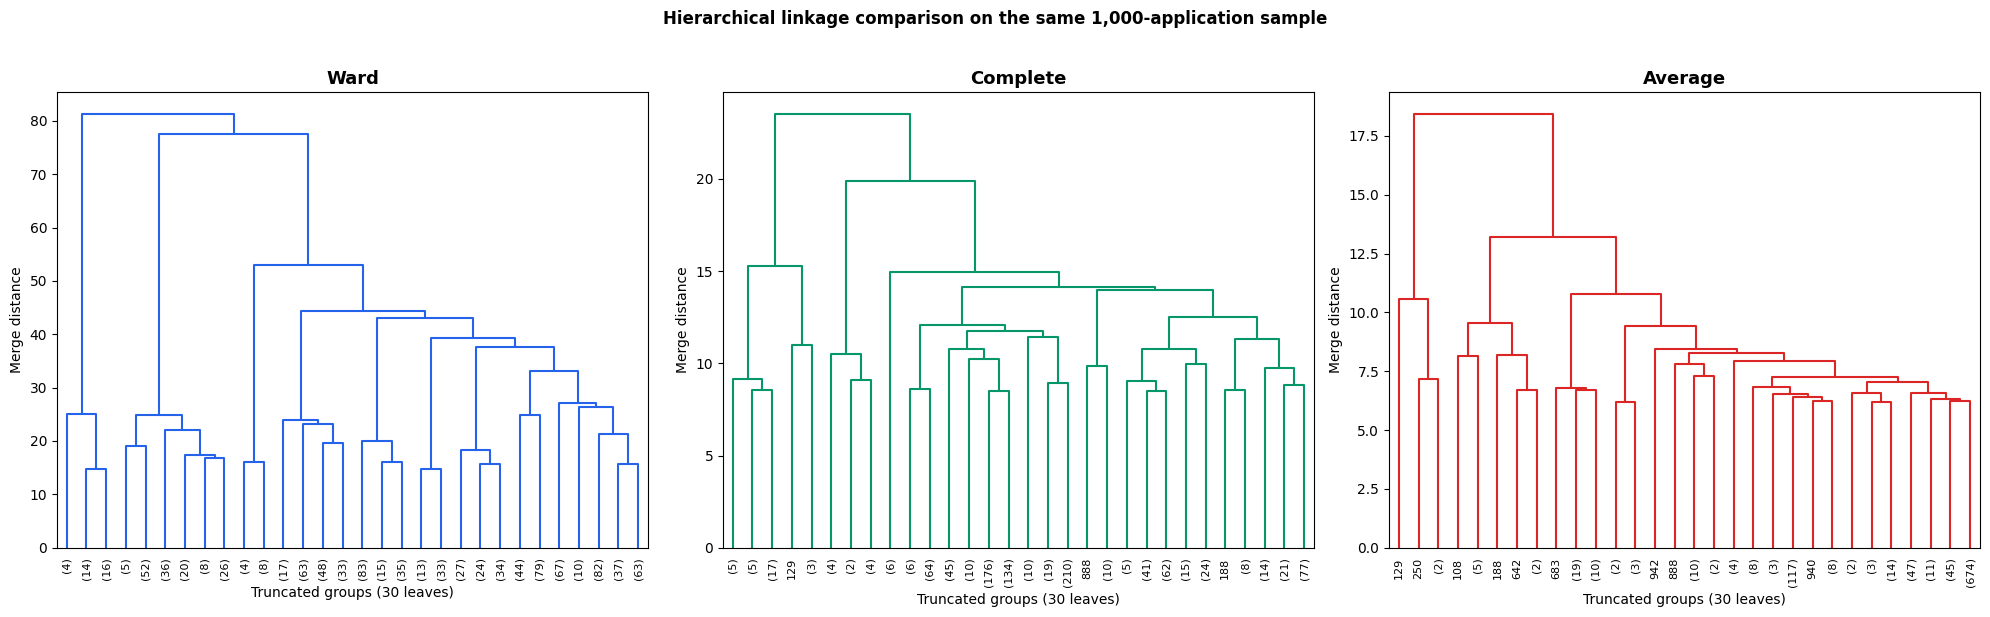

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2563EB', '#059669', '#DC2626']
for ax, method, color in zip(axes, linkage_methods, colors):
    dendrogram(linkage_results[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0, above_threshold_color=color)
    ax.set_title(method.title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Truncated groups (30 leaves)'); ax.set_ylabel('Merge distance')
plt.suptitle(f'Hierarchical linkage comparison on the same {len(subcenters):,}-application sample',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cluster maps in 2D

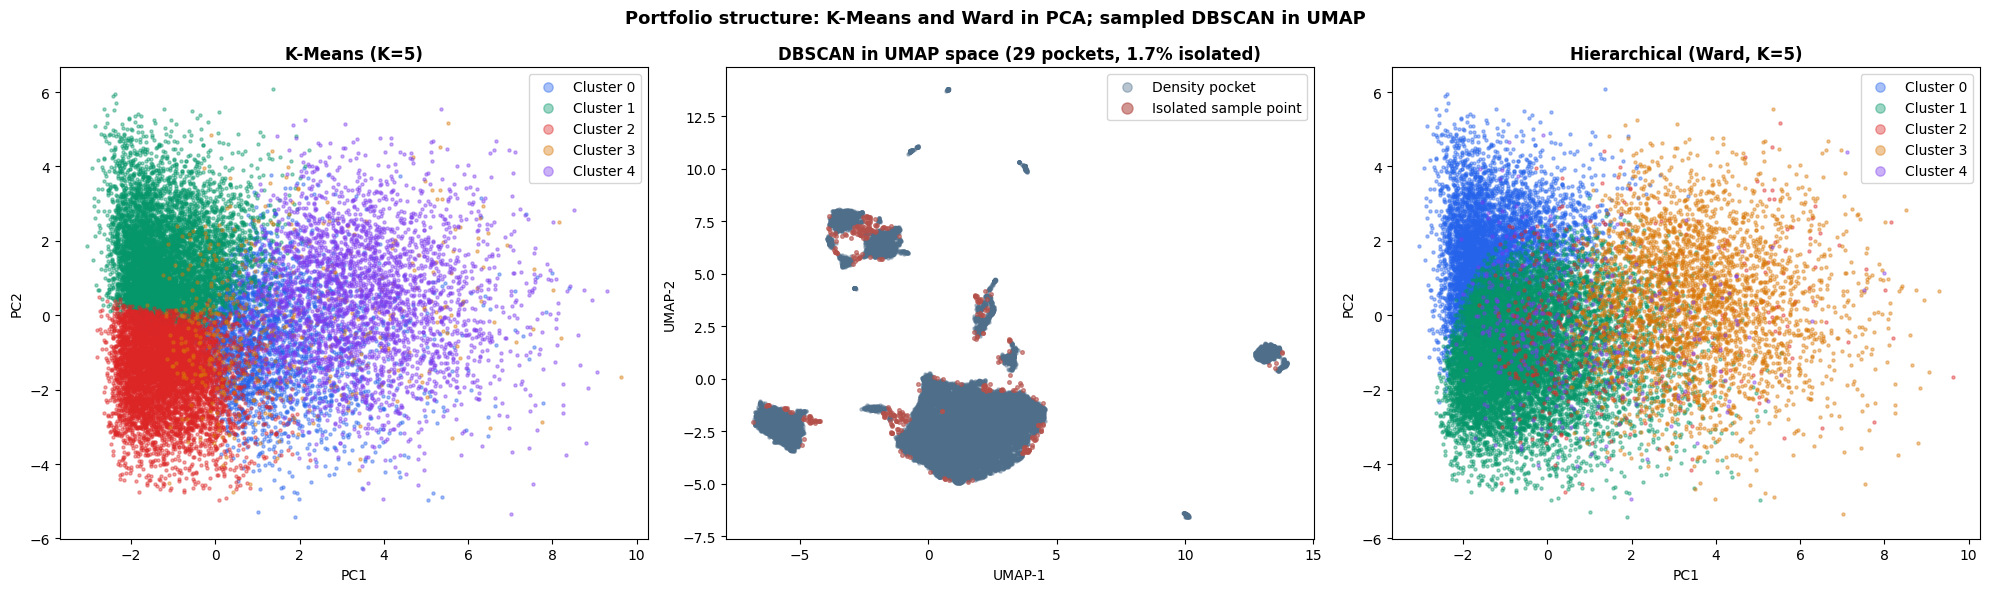

In [15]:
VIZ = 20000
rng4 = np.random.default_rng(RANDOM_SEED)
viz_idx = rng4.choice(len(X_2d), size=VIZ, replace=False)
COLORS = ['#2563EB', '#059669', '#DC2626', '#D97706', '#7C3AED']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cid in range(K_OPTIMAL):
    mask = kmeans_labels[viz_idx] == cid
    axes[0].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[0].set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

viz_db_n = min(VIZ, len(dbscan_idx))
db_lbl = dbscan_labels[:viz_db_n]
noise_mask = db_lbl == -1
axes[1].scatter(X_umap[:viz_db_n][~noise_mask, 0], X_umap[:viz_db_n][~noise_mask, 1],
                c='#4E6E8A', label='Density pocket', alpha=0.4, s=5)
axes[1].scatter(X_umap[:viz_db_n][noise_mask, 0], X_umap[:viz_db_n][noise_mask, 1],
                c='#B4504A', label='Isolated sample point', alpha=0.6, s=7)
axes[1].set_title(f'DBSCAN in UMAP space ({n_clusters_db} pockets, {pct_noise:.1f}% isolated)', fontweight='bold')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=3)

for cid in range(K_OPTIMAL):
    mask = hier_labels[viz_idx] == cid
    axes[2].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[2].set_title(f'Hierarchical (Ward, K={K_OPTIMAL})', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=3)

plt.suptitle('Portfolio structure: K-Means and Ward in PCA; sampled DBSCAN in UMAP', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save the cluster labels

In [16]:
labels_df = pd.DataFrame({
    'ROW_ID': np.arange(len(X_cluster)),
    'CLUSTER_KMEANS': kmeans_labels,
    'CLUSTER_HIER': hier_labels,
})
if 'SK_ID_CURR' in df.columns:
    labels_df.insert(1, 'SK_ID_CURR', df['SK_ID_CURR'].values)
# The density label now covers every application, so there is no missing state
# and no sampled denominator to carry downstream.
labels_df['CLUSTER_DBSCAN'] = dbscan_full_labels.astype(float)
labels_df['IS_OUTLIER'] = (labels_df['CLUSTER_DBSCAN'] == -1).astype('Int8')
assert labels_df['CLUSTER_DBSCAN'].notna().all(), 'every application must carry a density label'

def write_csv_atomic(frame, path):
    # Write beside the target, then atomically replace it. This avoids a
    # Windows failure seen when pandas truncates an existing dashboard
    # artefact while a filesystem indexer briefly holds a handle.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp.csv')
    frame.to_csv(temp, index=False)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

write_csv_atomic(labels_df, OUT_DIR / 'cluster_labels.csv')
write_csv_atomic(labels_df, PROJECT_ROOT / 'datasets/final/cluster_labels.csv')
print('Saved cluster_labels.csv to:')
print(f'  {OUT_DIR / "cluster_labels.csv"}')
print(f'  {PROJECT_ROOT / "datasets/final/cluster_labels.csv"}  (for Phase 3 and 4)')

viz_export = pd.DataFrame({
    'PC1': X_2d[viz_idx, 0],
    'PC2': X_2d[viz_idx, 1],
    'CLUSTER_KMEANS': kmeans_labels[viz_idx],
})
write_csv_atomic(viz_export, OUT_DIR / 'cluster_viz_sample.csv')
print(f'Saved cluster_viz_sample.csv ({len(viz_export):,} rows for the dashboard)')
labels_df.head()


Saved cluster_labels.csv to:
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\cluster_labels.csv
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\datasets\final\cluster_labels.csv  (for Phase 3 and 4)
Saved cluster_viz_sample.csv (20,000 rows for the dashboard)


,ROW_ID,SK_ID_CURR,CLUSTER_KMEANS,CLUSTER_HIER,CLUSTER_DBSCAN,IS_OUTLIER
0,0,100002,2,4,0.0,0
1,1,100003,1,0,0.0,0
2,2,100004,2,1,0.0,0
3,3,100006,2,1,0.0,0
4,4,100007,1,1,0.0,0


## 9. Cluster profiling: what makes each segment different

For every feature we take its mean per cluster and compare it with the portfolio mean, measured in portfolio standard deviations. The features with the largest absolute standardized differences are the ones that set a cluster apart. This is a comparison unit, not a percentage change in the original feature.

In [17]:
TOP_N = 10
df_prof = pd.concat([df.reset_index(drop=True), labels_df[['CLUSTER_KMEANS']].reset_index(drop=True)], axis=1)
feat_cols = [c for c in df_prof.columns if c not in ['SK_ID_CURR', 'CLUSTER_KMEANS'] and pd.api.types.is_numeric_dtype(df_prof[c])]

profiles = df_prof.groupby('CLUSTER_KMEANS')[feat_cols].mean()
global_mean = df_prof[feat_cols].mean()
global_std = df_prof[feat_cols].std().replace(0, np.nan)
std_diff = profiles.sub(global_mean).div(global_std)

profiles.to_csv(OUT_DIR / 'cluster_profiles.csv')
print(f'Saved cluster_profiles.csv ({profiles.shape[0]} clusters x {profiles.shape[1]} features)')

summary_rows = []
top_features = {}
for cid in std_diff.index:
    row = std_diff.loc[cid].abs().sort_values(ascending=False)
    top_cols = row.head(TOP_N).index.tolist()
    top_df = pd.DataFrame({
        'feature': top_cols,
        'std_diff': std_diff.loc[cid, top_cols].values,
        'direction': ['ABOVE' if v > 0 else 'BELOW' for v in std_diff.loc[cid, top_cols].values],
    }).sort_values('std_diff', key=abs, ascending=False)
    top_features[cid] = top_df
    for _, r in top_df.iterrows():
        summary_rows.append({'cluster_id': cid, 'feature': r['feature'], 'std_diff': round(r['std_diff'], 3), 'direction': r['direction']})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'cluster_summary.csv', index=False)
print(f'Saved cluster_summary.csv')

for cid in sorted(top_features.keys()):
    n = (labels_df['CLUSTER_KMEANS'] == cid).sum()
    pct = n / len(labels_df) * 100
    print(f'\n{"="*70}\nCLUSTER {cid} - {n:,} applications ({pct:.1f}%)\n{"-"*70}')
    for _, r in top_features[cid].iterrows():
        arrow = 'up' if r['direction'] == 'ABOVE' else 'down'
        print(f'  {r["feature"]:42s} {r["std_diff"]:>+7.2f} SD  {arrow} {r["direction"]}')

Saved cluster_profiles.csv (5 clusters x 41 features)
Saved cluster_summary.csv

CLUSTER 0 - 51,614 applications (14.5%)
----------------------------------------------------------------------
  PREV_COUNT                                   +1.45 SD  up ABOVE
  PREV_REFUSED_COUNT                           +1.25 SD  up ABOVE
  AMT_REQ_CREDIT_BUREAU_YEAR                   +1.06 SD  up ABOVE
  POS_MONTHS_COUNT                             +1.02 SD  up ABOVE
  PREV_APPROVAL_RATE                           -0.65 SD  down BELOW
  BUREAU_COUNT                                 +0.47 SD  up ABOVE
  INST_COUNT                                   +0.43 SD  up ABOVE
  CC_UTILIZATION_MEAN                          -0.33 SD  down BELOW
  CREDIT_TO_INCOME                             -0.32 SD  down BELOW
  EXT_SOURCE_3                                 -0.32 SD  down BELOW

CLUSTER 1 - 123,344 applications (34.6%)
----------------------------------------------------------------------
  AMT_CREDIT               

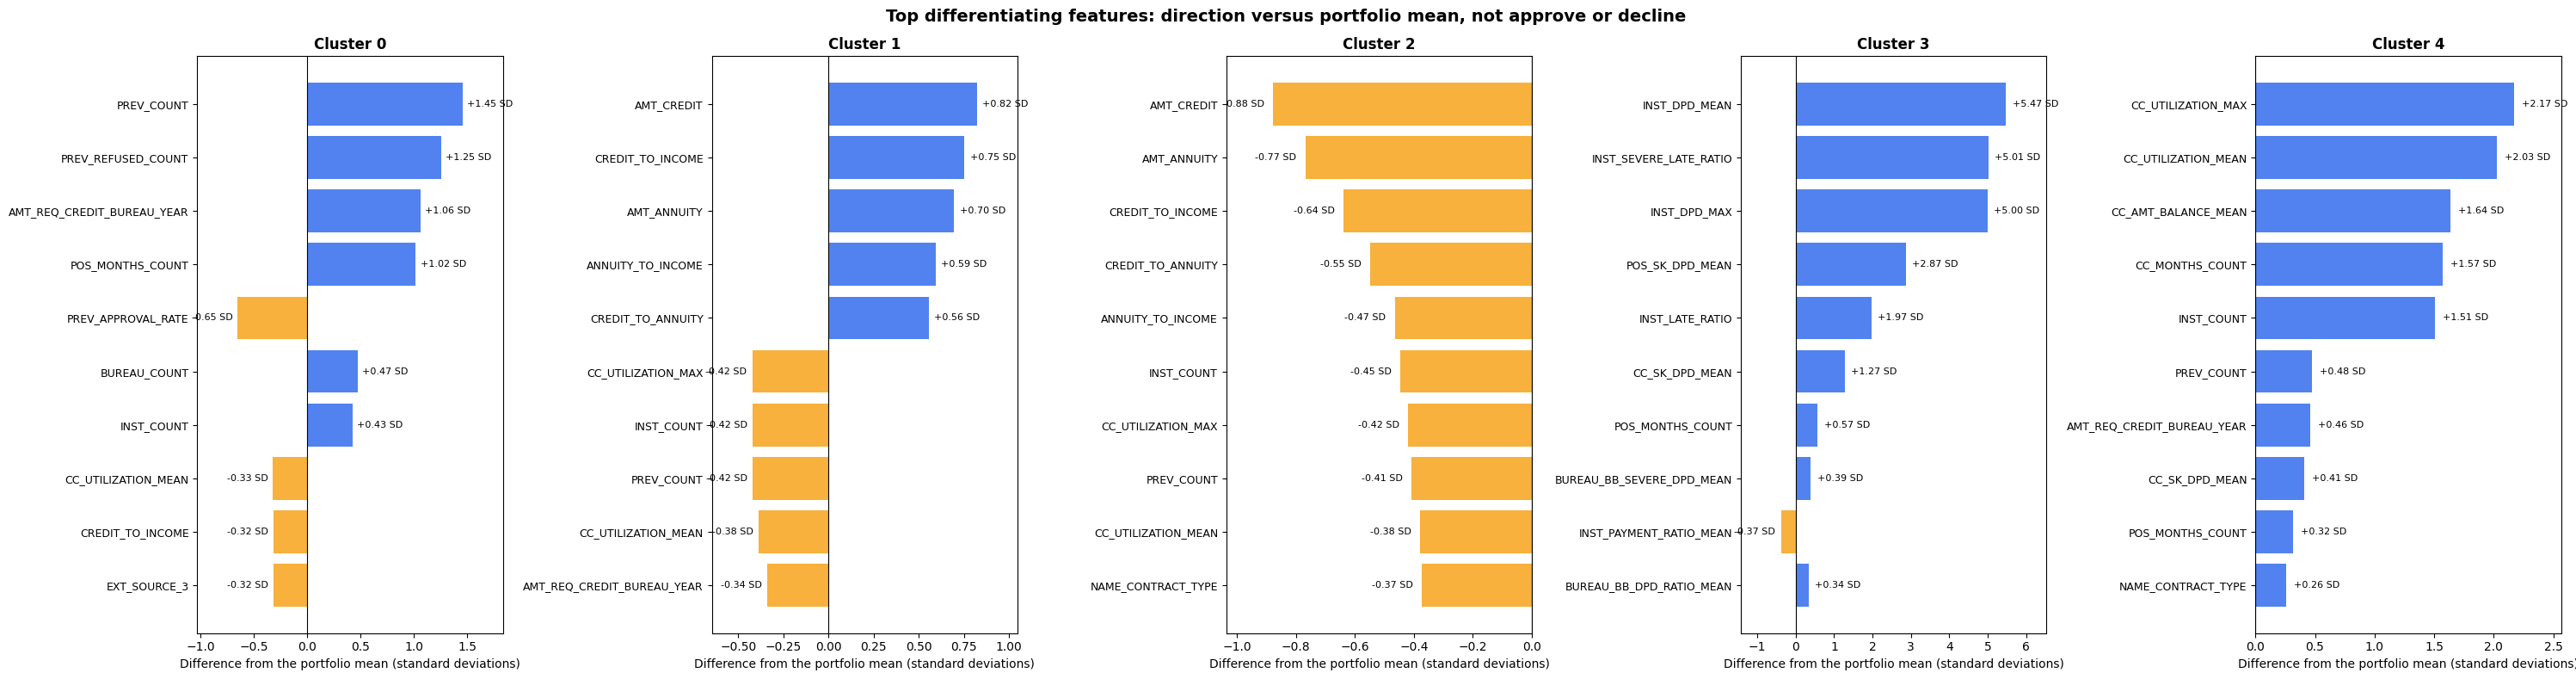

In [18]:
n_clusters = len(top_features)
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 8))
if n_clusters == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(top_features.keys())):
    tdf = top_features[cid].head(TOP_N)
    values = tdf['std_diff'].values
    labels = tdf['feature'].values
    colors_bar = ['#2563EB' if v > 0 else '#F59E0B' for v in values]
    bars = ax.barh(range(len(values)), values, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from the portfolio mean (standard deviations)')
    ax.set_title(f'Cluster {cid}', fontweight='bold')
    ax.invert_yaxis()
    label_pad = max(np.max(np.abs(values)) * 0.03, 0.03)
    for bar, val in zip(bars, values):
        x = val + (label_pad if val >= 0 else -label_pad)
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.2f} SD', va='center', fontsize=8, ha='left' if val >= 0 else 'right')
    ax.margins(x=0.18)
plt.suptitle('Top differentiating features: direction versus portfolio mean, not approve or decline', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'cluster_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business interpretation and segment naming

The most distinctive features are translated into plain segment names and review questions. These names describe patterns across the 356,255 combined applications; they are not applicant risk grades. `Lower-Intensity Credit Footprint` means lower product activity relative to the other segments, not an absence of usable history. Card utilisation, balances, arrears, and repayment measures come from previous Home Credit accounts and payment records. They describe recorded history, not a verified current balance or current payment problem. The external scores are opaque supporting indicators, so they are used only to prompt corroboration with direct bureau, income, and repayment evidence. A reviewer still needs to verify source coverage, recency, current obligations, and affordability before acting. Names and sizes are saved to `cluster_names.csv` so later phases use full business names instead of cluster numbers that can change between runs.

In [19]:
# Assign one unique, descriptive name to each cluster from its dominant
# business pattern. Names describe portfolio geometry; they are not credit
# decisions and must never replace applicant-level repayment assessment.
def mean_available(frame, columns):
    cols = [c for c in columns if c in frame.columns]
    return frame[cols].mean(axis=1) if cols else pd.Series(0.0, index=frame.index)

score_table = pd.DataFrame(index=profiles.index)
score_table['repayment_stress'] = mean_available(profiles, [
    'INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO',
    'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'])
score_table['card_intensity'] = mean_available(profiles, [
    'CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN', 'CC_MONTHS_COUNT'])
score_table['relationship_depth'] = mean_available(profiles, [
    'PREV_COUNT', 'BUREAU_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'])
score_table['borrowing_scale'] = mean_available(profiles, [
    'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME'])

remaining = set(int(c) for c in profiles.index)
assignments = {}
def take_highest(score, name):
    cid = int(score.loc[list(remaining)].idxmax())
    assignments[cid] = name
    remaining.remove(cid)

take_highest(score_table['repayment_stress'], 'Repayment-Stress History')
take_highest(score_table['card_intensity'], 'Historical Card-Use Intensity')
take_highest(score_table['relationship_depth'], 'History-Rich Credit User')
take_highest(score_table['borrowing_scale'], 'Larger-Loan Affordability')
assignments[remaining.pop()] = 'Lower-Intensity Credit Footprint'

META = {
    'Repayment-Stress History': {
        'risk': 'Repayment review',
        'profile': 'Late payments in recorded instalment history are the strongest differentiating pattern.',
        'watch': 'When the delays happened, how severe they were, whether they were cured, and current affordability.',
        'action': 'Review the repayment timeline and current affordability. For existing hardship, follow the customer-contact or restructuring policy.'},
    'Historical Card-Use Intensity': {
        'risk': 'Historical revolving-credit review',
        'profile': 'Recorded use of previous Home Credit card accounts dominates this profile.',
        'watch': 'Whether a revolving facility is still open, plus its verified current balance, utilisation, arrears, and affordability.',
        'action': 'Use the history to focus the review. Assess limit suitability only after confirming that a current revolving facility exists and verifying its present balance and payment status.'},
    'History-Rich Credit User': {
        'risk': 'Credit-history review',
        'profile': 'This profile has longer internal and external credit history than the other groups.',
        'watch': 'Whether earlier refusals or arrears remain relevant now.',
        'action': 'Compare earlier decisions with current obligations. Use the extra history to verify the present position, not to assume it.'},
    'Larger-Loan Affordability': {
        'risk': 'Affordability review',
        'profile': 'Larger current-loan amounts and scheduled payments distinguish this profile.',
        'watch': 'Verified income, total obligations, and whether the scheduled payment remains affordable if income falls.',
        'action': 'Confirm sustainable income and test the proposed payment under a lower-income scenario before any credit action.'},
    'Lower-Intensity Credit Footprint': {
        'risk': 'Standard evidence review',
        'profile': 'Lower product activity and smaller loan amounts than the other portfolio segments.',
        'watch': 'Which sources are actually missing; lower activity does not mean that useful history is absent or that payment risk is lower.',
        'action': 'Use standard underwriting. Ask for permitted supporting evidence only when a relevant source is genuinely unavailable.'},
}

SLUG_BY_NAME = {
    'History-Rich Credit User': 'history_rich',
    'Lower-Intensity Credit Footprint': 'lower_intensity',
    'Historical Card-Use Intensity': 'card_intensive',
    'Larger-Loan Affordability': 'larger_loan',
    'Repayment-Stress History': 'repayment_stress',
}
names_rows = []
for cid in sorted(assignments):
    name = assignments[cid]
    meta = META[name]
    names_rows.append({
        'cluster_id': cid,
        'segment_name': name,
        'slug': SLUG_BY_NAME[name],
        'review_focus': meta['risk'],
        'profile_summary': meta['profile'],
        'watch_items': meta['watch'],
        'recommended_action': meta['action'],
        'n_applicants': int((labels_df['CLUSTER_KMEANS'] == cid).sum()),
    })
    print(f'Cluster {cid}: {name}; review focus: {meta["risk"]}')

names_df = pd.DataFrame(names_rows)
write_csv_atomic(names_df, OUT_DIR / 'cluster_names.csv')
write_csv_atomic(names_df, PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print('\nSaved cluster_names.csv (results + datasets/final):')
print(names_df.to_string(index=False))


Cluster 0: History-Rich Credit User; review focus: Credit-history review
Cluster 1: Larger-Loan Affordability; review focus: Affordability review
Cluster 2: Lower-Intensity Credit Footprint; review focus: Standard evidence review
Cluster 3: Repayment-Stress History; review focus: Repayment review
Cluster 4: Historical Card-Use Intensity; review focus: Historical revolving-credit review

Saved cluster_names.csv (results + datasets/final):
 cluster_id                     segment_name             slug                       review_focus                                                                         profile_summary                                                                                                                   watch_items                                                                                                                                                                 recommended_action  n_applicants
          0         History-Rich Credit User     histo

---
Phase 2 done. The artefacts are in `results/phase2_clustering/`, and `datasets/final/cluster_labels.csv` carries the segment assignments forward to Phase 3 and Phase 4.

---
## 11. Comparable business view and DBSCAN map

The earlier small multiples show the strongest features separately for each
cluster, but separate axes make comparison unnecessarily hard. The heatmap
below puts all five segments on one scale using six domain dimensions. Blue
means "more of the named dimension" and orange means "less"; the colours do
not mean approve or decline. A second view shows the DBSCAN UMAP
map so readers can inspect the isolated points instead of seeing only a count.


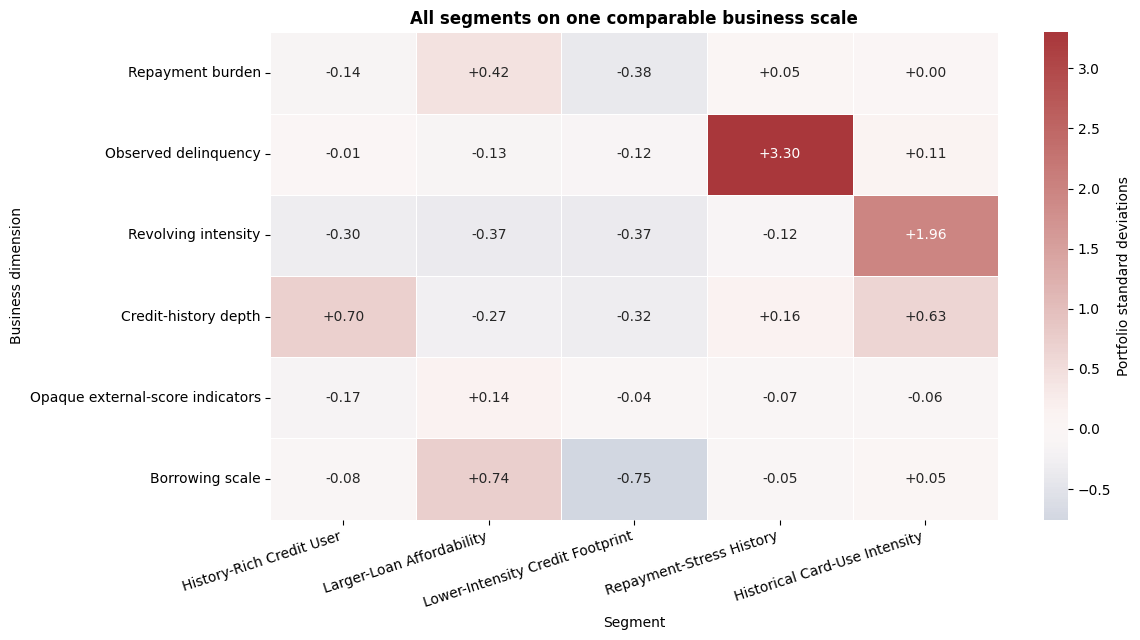

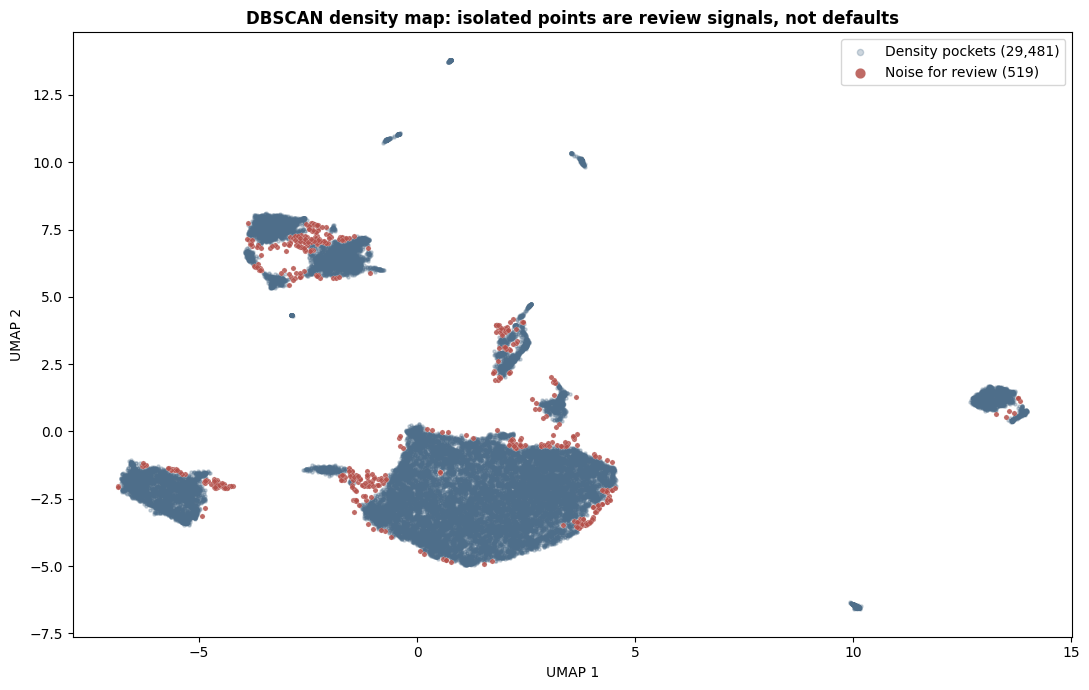

Saved comparable cluster view, business medians, action matrix, and 30,000-row DBSCAN map.


In [20]:
import seaborn as sns

business = pd.read_csv(PROJECT_ROOT / 'datasets/final/features_business.csv')
business_labeled = business.merge(
    labels_df[['ROW_ID', 'CLUSTER_KMEANS']], on='ROW_ID', how='inner', validate='one_to_one')
NAME_BY_CID = dict(zip(names_df['cluster_id'], names_df['segment_name']))
business_labeled['Segment'] = business_labeled['CLUSTER_KMEANS'].map(NAME_BY_CID)

dimension_features = {
    'Repayment burden': ['ANNUITY_TO_INCOME', 'CREDIT_TO_INCOME', 'BUREAU_DEBT_TO_CREDIT_RATIO'],
    'Observed delinquency': ['INST_DPD_MAX', 'INST_LATE_RATIO', 'INST_SEVERE_LATE_RATIO',
                             'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'],
    'Revolving intensity': ['CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN'],
    'Credit-history depth': ['BUREAU_COUNT', 'PREV_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'],
    'Opaque external-score indicators': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'Borrowing scale': ['AMT_CREDIT', 'AMT_ANNUITY'],
}

numeric = business_labeled.select_dtypes(include=np.number).copy()
standardized = pd.DataFrame(index=numeric.index)
for col in sorted({c for cols in dimension_features.values() for c in cols if c in numeric.columns}):
    values = numeric[col].replace([np.inf, -np.inf], np.nan)
    lo, hi = values.quantile([.01, .99])
    clipped = values.clip(lo, hi)
    std = clipped.std()
    standardized[col] = (clipped - clipped.mean()) / std if std and np.isfinite(std) else 0.0

dimensions = pd.DataFrame(index=business_labeled.index)
for dimension, columns in dimension_features.items():
    use = [c for c in columns if c in standardized.columns]
    dimensions[dimension] = standardized[use].mean(axis=1)
dimensions['CLUSTER_KMEANS'] = business_labeled['CLUSTER_KMEANS'].values
comparison = dimensions.groupby('CLUSTER_KMEANS').mean().T
comparison.columns = [NAME_BY_CID[int(c)] for c in comparison.columns]
comparison = comparison[names_df.sort_values('cluster_id')['segment_name'].tolist()]

comparison_long = comparison.rename_axis('business_dimension').reset_index().melt(
    id_vars='business_dimension', var_name='Segment', value_name='portfolio_sd')
comparison_long.to_csv(OUT_DIR / 'cluster_comparison_long.csv', index=False)

business_summary = business_labeled.groupby(['CLUSTER_KMEANS', 'Segment']).agg(
    applicants=('SK_ID_CURR', 'size'),
    median_income=('AMT_INCOME_TOTAL', 'median'),
    median_credit=('AMT_CREDIT', 'median'),
    median_credit_to_income=('CREDIT_TO_INCOME', 'median'),
    median_annuity_to_income=('ANNUITY_TO_INCOME', 'median'),
    median_installment_late_share=('INST_LATE_RATIO', 'median'),
    median_external_score_2=('EXT_SOURCE_2', 'median'),
    median_card_utilisation=('CC_UTILIZATION_MEAN', 'median'),
).reset_index()
business_summary.to_csv(OUT_DIR / 'cluster_business_summary.csv', index=False)
names_df[['cluster_id', 'segment_name', 'profile_summary', 'watch_items', 'recommended_action']].to_csv(
    OUT_DIR / 'cluster_action_matrix.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(comparison, cmap='vlag', center=0, annot=True, fmt='+.2f',
            linewidths=.6, cbar_kws={'label': 'Portfolio standard deviations'}, ax=ax)
ax.set_xlabel('Segment'); ax.set_ylabel('Business dimension')
ax.set_title('All segments on one comparable business scale', fontweight='bold')
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_cluster_comparison.png', dpi=170, bbox_inches='tight')
plt.show()

dbscan_export = pd.DataFrame({
    'ROW_ID': dbscan_idx,
    'SK_ID_CURR': df.iloc[dbscan_idx]['SK_ID_CURR'].to_numpy(),
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'DBSCAN_LABEL': dbscan_labels,
    'IS_NOISE': (dbscan_labels == -1).astype(int),
    'PORTFOLIO_DBSCAN_LABEL': dbscan_full_labels[dbscan_idx],
    'PORTFOLIO_IS_NOISE': (dbscan_full_labels[dbscan_idx] == -1).astype(int),
    'CLUSTER_KMEANS': kmeans_labels[dbscan_idx],
})
dbscan_export['Segment'] = dbscan_export['CLUSTER_KMEANS'].map(NAME_BY_CID)
dbscan_export.to_csv(OUT_DIR / 'dbscan_umap_sample.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 7))
dense = dbscan_export[dbscan_export['IS_NOISE'] == 0]
noise = dbscan_export[dbscan_export['IS_NOISE'] == 1]
ax.scatter(dense['UMAP1'], dense['UMAP2'], s=5, alpha=.28, c='#4E6E8A',
           label=f'Density pockets ({len(dense):,})')
ax.scatter(noise['UMAP1'], noise['UMAP2'], s=14, alpha=.85, c='#B4504A',
           edgecolors='white', linewidths=.15, label=f'Noise for review ({len(noise):,})')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('DBSCAN density map: isolated points are review signals, not defaults', fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_dbscan_umap.png', dpi=170, bbox_inches='tight')
plt.show()

print(f'Saved comparable cluster view, business medians, action matrix, and {len(dbscan_export):,}-row DBSCAN map.')


---
## 12. Is the amount concentration a discovery or an arithmetic certainty?

### Why this test is mandatory

Segment names in Section 10 are assigned from the feature families that separate each segment, and one of those families is borrowing scale: `AMT_CREDIT`, `AMT_ANNUITY`, and `CREDIT_TO_INCOME`. The segment that scores highest on that family is therefore, by construction, the segment holding the largest loans.

Saying afterwards that this segment carries a large share of the portfolio's recorded loan value would then be close to a tautology. Any subset selected for having large loans concentrates loan value. Worse, a right-skewed amount distribution concentrates value in its upper part no matter how the subset is chosen, so a number such as "a third of applications carry more than half the value" can look striking while being a property of the distribution rather than a finding.

### How the test works

The cell below places the observed concentration between two reference points computed on the same portfolio:

* the **null**, where a segment of the same size carries exactly its population share of the amount, and
* the **ceiling**, the share carried by the same number of applications selected purely by sorting on recorded loan amount, which no segmentation can beat.

The **capture ratio** is the position between them. A ratio near 1.00 means the segmentation is doing almost nothing except sorting by loan size, and the concentration must be reported as arithmetic. A ratio well below 1.00 means the segment is defined by more than amount, and the concentration carries information. The Gini coefficient of the amount distribution is printed alongside, because it sets how much concentration is available in the first place.

This is the honest way to report the number: not as a headline on its own, but with the two references that make it interpretable.


Gini of recorded loan amount across the portfolio: 0.363
The bottom half of applications carries 24.33% of the amount.

                         Segment  application_share  amount_share  ceiling_share  capture_ratio
       Larger-Loan Affordability              34.62         53.21          60.72          0.712
   Historical Card-Use Intensity              15.31         16.03          34.33          0.038
Lower-Intensity Credit Footprint              33.44         15.74          59.36         -0.683
        History-Rich Credit User              14.49         12.96          32.92         -0.083
        Repayment-Stress History               2.14          2.07           7.01         -0.015

Larger-Loan Affordability: 34.62% of applications carry 53.21% of recorded loan value.
  Null for a segment this size      : 34.62%
  Ceiling from sorting on amount    : 60.72%
  Capture ratio                     : 0.712
  A capture ratio this high means the concentration is close to what sorting on
  

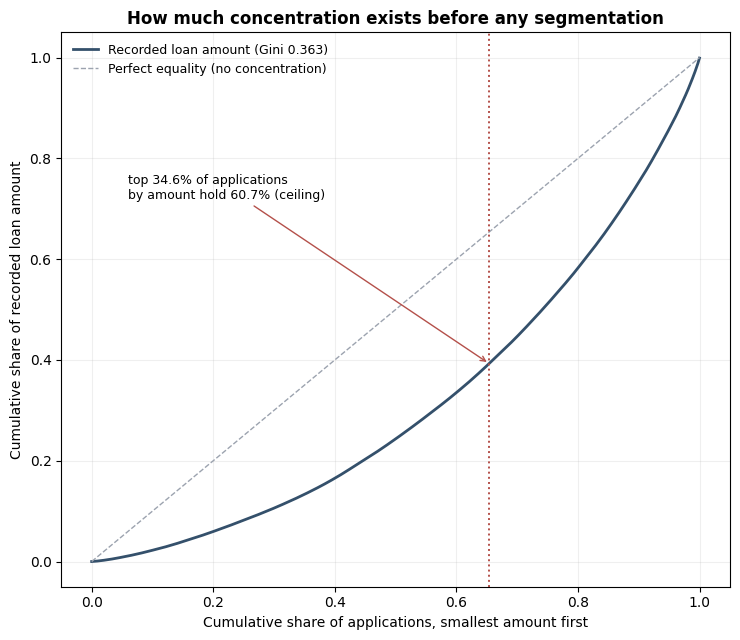

In [21]:
# ---------------------------------- calibrated concentration of recorded amounts
business_amounts = business_labeled[['SK_ID_CURR', 'CLUSTER_KMEANS']].copy()
amount_col = 'SOURCE_AMT_CREDIT' if 'SOURCE_AMT_CREDIT' in business_labeled.columns else 'AMT_CREDIT'
annuity_col = 'SOURCE_AMT_ANNUITY' if 'SOURCE_AMT_ANNUITY' in business_labeled.columns else 'AMT_ANNUITY'
business_amounts['amount'] = business_labeled[amount_col].to_numpy()
business_amounts['annuity'] = business_labeled[annuity_col].to_numpy()
business_amounts['Segment'] = business_amounts['CLUSTER_KMEANS'].map(NAME_BY_CID)

total_amount = business_amounts['amount'].sum()
total_annuity = business_amounts['annuity'].sum()
sorted_amounts = np.sort(business_amounts['amount'].to_numpy())[::-1]
cumulative_amounts = np.cumsum(sorted_amounts)

rows = []
for segment, group in business_amounts.groupby('Segment'):
    size = len(group)
    app_share = size / len(business_amounts)
    amount_share = group['amount'].sum() / total_amount
    ceiling = cumulative_amounts[size - 1] / total_amount
    capture = ((amount_share - app_share) / (ceiling - app_share)) if ceiling > app_share else np.nan
    rows.append({
        'Segment': segment, 'applications': size,
        'application_share': app_share, 'amount_share': amount_share,
        'annuity_share': group['annuity'].sum() / total_annuity,
        'null_share': app_share, 'ceiling_share': ceiling,
        'capture_ratio': capture,
        'excess_over_null_pp': (amount_share - app_share) * 100,
    })
concentration = pd.DataFrame(rows).sort_values('amount_share', ascending=False)

x = np.sort(business_amounts['amount'].to_numpy())
cum = np.cumsum(x)
gini = float((len(x) + 1 - 2 * (cum.sum() / cum[-1])) / len(x))
concentration['portfolio_gini'] = gini
concentration.to_csv(OUT_DIR / 'segment_amount_concentration_calibrated.csv', index=False)

print(f'Gini of recorded loan amount across the portfolio: {gini:.3f}')
print(f'The bottom half of applications carries {x[:len(x)//2].sum() / total_amount:.2%} of the amount.\n')
print(concentration[['Segment', 'application_share', 'amount_share', 'ceiling_share',
                     'capture_ratio']].assign(
    application_share=lambda d: (d.application_share * 100).round(2),
    amount_share=lambda d: (d.amount_share * 100).round(2),
    ceiling_share=lambda d: (d.ceiling_share * 100).round(2),
    capture_ratio=lambda d: d.capture_ratio.round(3)).to_string(index=False))

top = concentration.iloc[0]
print(f"\n{top['Segment']}: {top['application_share']:.2%} of applications carry "
      f"{top['amount_share']:.2%} of recorded loan value.")
print(f"  Null for a segment this size      : {top['null_share']:.2%}")
print(f"  Ceiling from sorting on amount    : {top['ceiling_share']:.2%}")
print(f"  Capture ratio                     : {top['capture_ratio']:.3f}")
print('  A capture ratio this high means the concentration is close to what sorting on')
print('  loan size alone would produce, so it is reported as a calibrated fact about the')
print('  amount distribution, not as an independent discovery. Appendix G of REPORT.md')
print('  builds the finding on the alignment between amount and review attention instead.')

# ---------------------------------------------------------------- Lorenz curve
fig, ax = plt.subplots(figsize=(7.5, 6.5))
lorenz_x = np.arange(1, len(x) + 1) / len(x)
lorenz_y = cum / cum[-1]
step = max(1, len(x) // 4000)
ax.plot(lorenz_x[::step], lorenz_y[::step], color='#34506B', linewidth=2,
        label=f'Recorded loan amount (Gini {gini:.3f})')
ax.plot([0, 1], [0, 1], color='#9CA3AF', linestyle='--', linewidth=1,
        label='Perfect equality (no concentration)')
seg_share = 1 - top['application_share']
ax.axvline(seg_share, color='#B4504A', linestyle=':', linewidth=1.4)
ax.annotate(f"top {top['application_share']:.1%} of applications\nby amount hold "
            f"{top['ceiling_share']:.1%} (ceiling)",
            xy=(seg_share, np.interp(seg_share, lorenz_x, lorenz_y)),
            xytext=(0.06, 0.72), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#B4504A', lw=1))
ax.set_xlabel('Cumulative share of applications, smallest amount first')
ax.set_ylabel('Cumulative share of recorded loan amount')
ax.set_title('How much concentration exists before any segmentation', fontweight='bold')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(alpha=.2)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_amount_lorenz.png', dpi=170, bbox_inches='tight')
plt.show()


---
## 13. Alternatives considered and rejected

Every method choice in this phase had at least one credible competitor. Recording which competitors were tried, what they scored, and why they were not adopted turns a stated preference into a defended decision, and it lets a reader disagree with the reasoning rather than guess at it. The register below is written from the numbers produced above in this same notebook, not from general practice.


In [22]:
alternatives = pd.DataFrame([
    {
        'decision': 'Number of segments (K)',
        'chosen': f'K = {K_OPTIMAL}',
        'alternatives_tested': 'K = 2 through 10, three seeds each at K = 5, 6, 7',
        'evidence': (f"K=2 silhouette {k_df.loc[k_df.k.eq(2), 'silhouette'].iloc[0]:.3f} but "
                     f"{k_df.loc[k_df.k.eq(2), 'max_cluster_share'].iloc[0]:.1%} of applications in one group; "
                     f"K=7 silhouette {k_df.loc[k_df.k.eq(7), 'silhouette'].iloc[0]:.3f} and "
                     f"Davies-Bouldin {k_df.loc[k_df.k.eq(7), 'davies_bouldin'].iloc[0]:.3f}, both better than "
                     f"K=5, but seed ARI {stability_mean.loc[7]:.3f}"),
        'why_rejected': ('K=2 cannot support five differentiated review workflows. K=6 and K=7 score better on '
                         'geometry but their labels move between random seeds, so a segment would not mean the '
                         'same thing on two runs and no review process could be attached to it.'),
        'cost_accepted': (f"K=5 is not the silhouette optimum ({k_df.loc[k_df.k.eq(5), 'silhouette'].iloc[0]:.3f} "
                          f"against {k_df.silhouette.max():.3f} at K={int(k_df.loc[k_df.silhouette.idxmax(), 'k'])})."),
    },
    {
        'decision': 'Hierarchical linkage',
        'chosen': 'Ward',
        'alternatives_tested': 'complete, average, on the same 2,000-application sample',
        'evidence': (f"cophenetic correlation ward {cophenetic_frame.set_index('linkage').loc['ward', 'cophenetic_correlation']:.3f}, "
                     f"complete {cophenetic_frame.set_index('linkage').loc['complete', 'cophenetic_correlation']:.3f}, "
                     f"average {cophenetic_frame.set_index('linkage').loc['average', 'cophenetic_correlation']:.3f}; "
                     f"largest group at K=5: ward {cophenetic_frame.set_index('linkage').loc['ward', 'largest_group_share']:.1%}, "
                     f"average {cophenetic_frame.set_index('linkage').loc['average', 'largest_group_share']:.1%}"),
        'why_rejected': ('Average linkage reproduces pairwise distances best but chains the sample into one '
                         'dominant group with tiny satellites, which cannot be operationalised as segments.'),
        'cost_accepted': 'Ward has the lowest distance fidelity of the three and this is reported with the finding.',
    },
    {
        'decision': 'Clustering space',
        'chosen': f'{N_PCA_CLUSTER} principal components ({cumvar[N_PCA_CLUSTER-1]:.1%} variance)',
        'alternatives_tested': f'{n_80} components (80% variance), {n_90} components (90%), all {X.shape[1]} raw features',
        'evidence': '; '.join(
            f"{int(r.n_components)} PCs: ARI {r.ari_vs_10pc:.3f} vs the 10-component labels, "
            f"silhouette {r.silhouette:.3f}"
            for r in pd.read_csv(OUT_DIR / 'pca_cluster_sensitivity.csv').itertuples()),
        'why_rejected': ('The higher-variance spaces reproduce almost the same partition, so the extra components '
                         'add computation and noise-sensitive axes without changing the segments.'),
        'cost_accepted': f'{cumvar[N_PCA_CLUSTER-1]:.1%} retained variance is below a conventional 80% rule, which is why the agreement check above is reported rather than the rule.',
    },
    {
        'decision': 'Categorical encoding for distance',
        'chosen': 'ordinal and frequency encoding, no one-hot',
        'alternatives_tested': 'one-hot encoding of organisation type, income type, education',
        'evidence': ('One-hot on a 16-sector field adds 15 sparse axes that jointly outweigh a single '
                     'standardised continuous feature, and forces every pair of sectors to sit at the same distance.'),
        'why_rejected': ('Euclidean distance would then be dominated by category bookkeeping rather than financial '
                         'behaviour; an earlier run also produced a perfectly collinear trio between the employment '
                         'sentinel, unknown organisation, and the pensioner category.'),
        'cost_accepted': 'Frequency encoding can place two unrelated sectors at the same coordinate when they are equally common; both encoded fields are therefore excluded from the mining matrix and kept only for profiling.',
    },
    {
        'decision': 'Density algorithm and space',
        'chosen': f'DBSCAN over all {len(X_cluster):,} applications in the 10-component PCA space',
        'alternatives_tested': 'DBSCAN on a 30,000-application UMAP embedding; full-portfolio UMAP',
        'evidence': (f"full-portfolio run completed with eps {EPS_FULL} and {n_noise_full:,} noise points "
                     f"({n_noise_full / len(X_cluster):.2%}); the UMAP sample gives "
                     f"{int((dbscan_labels == -1).sum()):,} noise on its 30,000 rows and agrees with the "
                     f"portfolio result at Jaccard {jaccard_space:.3f} on the rows both judged"),
        'why_rejected': ('An earlier version called the full run intractable. That was wrong: the expensive step is '
                         'UMAP, not DBSCAN, and the 10-component space needs no embedding. Full-portfolio UMAP '
                         'remains impractical, so the embedding is kept only as a picture.'),
        'cost_accepted': ('The eps knee is estimated from 30,000 query rows against an index fitted on all rows, '
                          'and the run takes roughly 25 minutes.'),
    },
    {
        'decision': 'Hierarchical clustering at full scale',
        'chosen': f'BIRCH over all {len(X_cluster):,} applications (threshold {BIRCH_THRESHOLD})',
        'alternatives_tested': ('exact agglomerative clustering on all rows; Ward on a kNN connectivity graph; '
                                'BIRCH at thresholds 0.5, 1.0, 1.5, 2.0 and 3.0; sampled Ward with '
                                'nearest-centre assignment'),
        'evidence': (f"exact linkage needs 63.46 billion pairwise distances and fails with a 242 GiB allocation "
                     f"error; BIRCH at threshold 0.5 leaves about 254,000 subclusters and hits the same wall, "
                     f"while threshold {BIRCH_THRESHOLD} compresses to {n_subclusters:,} subclusters and completes "
                     f"in seconds at ARI {birch_ari:.3f}; the sampled Ward contrast reports {ward_ari:.3f}"),
        'why_rejected': ('Exact linkage is an algorithmic wall, not a preference. Ward on a kNN connectivity graph '
                         'builds its graph cheaply but the agglomeration had not finished after 40 minutes. The '
                         'sampled nearest-centre approach is retained only as a contrast, because its Voronoi '
                         'assignment biases the comparison toward agreement.'),
        'cost_accepted': (f"BIRCH results depend materially on the threshold, and the full-portfolio solution puts "
                          f"{np.bincount(birch_labels, minlength=K_OPTIMAL).max() / len(birch_labels):.1%} of "
                          "applications into one group, so it validates K-Means weakly rather than confirming it."),
    },
])
alternatives.to_csv(OUT_DIR / 'method_alternatives_register.csv', index=False)
print(f'Saved method_alternatives_register.csv ({len(alternatives)} defended decisions)')
for _, row in alternatives.iterrows():
    print(f"\n{row['decision']}: chose {row['chosen']}")
    print(f"  tested   : {row['alternatives_tested']}")
    print(f"  rejected : {row['why_rejected']}")
    print(f"  cost     : {row['cost_accepted']}")


Saved method_alternatives_register.csv (6 defended decisions)

Number of segments (K): chose K = 5
  tested   : K = 2 through 10, three seeds each at K = 5, 6, 7
  rejected : K=2 cannot support five differentiated review workflows. K=6 and K=7 score better on geometry but their labels move between random seeds, so a segment would not mean the same thing on two runs and no review process could be attached to it.
  cost     : K=5 is not the silhouette optimum (0.148 against 0.268 at K=3).

Hierarchical linkage: chose Ward
  tested   : complete, average, on the same 2,000-application sample
  rejected : Average linkage reproduces pairwise distances best but chains the sample into one dominant group with tiny satellites, which cannot be operationalised as segments.
  cost     : Ward has the lowest distance fidelity of the three and this is reported with the finding.

Clustering space: chose 10 principal components (64.8% variance)
  tested   : 16 components (80% variance), 21 components (9